### Importation of the libraries 

In [1]:
%%capture

%pip -q install numpy 
%pip -q install pandas 
%pip -q install matplotlib 
%pip -q install seaborn 
%pip -q install scikit-learn 
%pip -q install scikit-optimize 
%pip -q install xgboost
%pip -q install openpyxl
%pip -q install tabulate
%pip -q install statsmodels
%pip -q install shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import RepeatedStratifiedKFold
from skopt.space import Real, Integer
from skopt import BayesSearchCV
from xgboost import XGBClassifier
import openpyxl

### Loading the Data

In [3]:
df = pd.read_excel("Veave - Analyse NTs_Adult_230126-R.xlsx", sheet_name="NTadu-R-stack")

<span style="font-weight: bold;">
With the info() command, I obtain information about the data structure, including the number of rows, columns, data types, and non-null values for each variable.
</span>

In [4]:
df.info() # here we can see the data types of each column and the number of non-null values. This will help us identify any missing data and understand the structure of our dataset.

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Projet           86 non-null     str    
 1   Cohort           86 non-null     str    
 2   Group            86 non-null     str    
 3   Cage             86 non-null     int64  
 4   ID               0 non-null      float64
 5   ID.2             86 non-null     str    
 6   Sample Name      0 non-null      float64
 7   Sex              86 non-null     str    
 8   Area             86 non-null     str    
 9   Sample Name.1    86 non-null     str    
 10  5HTP             86 non-null     object 
 11  Adénosine        86 non-null     object 
 12  Adrénaline       2 non-null      str    
 13  Dopamine         86 non-null     object 
 14  GABA             86 non-null     object 
 15  Glutamate        86 non-null     object 
 16  Glutamine        86 non-null     object 
 17  Kynurénine       86 non-null 

<span style="font-weight: bold;">
 The metabolite columns are shown as "object" due to the presence of a non-numeric value ("x") in one sample. </span>

In [5]:
mask = df["GABA"].apply(lambda x: isinstance(x, str)) # Some of the values in the "GABA" column are strings, which is causing issues when we try to convert the column to numeric values. We want to remove those rows from the dataframe so that we can work with numeric values only.
print(df.loc[mask]) # Print the rows where the "GABA" column contains strings to see what those values are

   Projet     Cohort Group  Cage  ID  ID.2  Sample Name     Sex Area  \
60  VEAVE  Cohorte 3  CONT    14 NaN  14-6          NaN  Female  HIP   

   Sample Name.1  ... GABA Glutamate Glutamine Kynurénine Noradrénaline  \
60         14-6_  ...    x         x         x          x             x   

   Normétanéphrine Sérotonine Tryptophane Tyramine Tyrosine  
60               x          x           x        x        x  

[1 rows x 24 columns]


<span style="font-weight: bold;">
After identifying this invalid entry, the corresponding row was removed </span>

In [6]:
df = df[~mask] # Remove that line from the dataframe
df = df.reset_index(drop=True) # Reset the index of the dataframe since we removed a row

<span style="font-weight: bold;">
 And the metabolite columns were converted to numeric format. </span>

In [7]:
nts = [
    "5HTP", "Adénosine", "Adrénaline", "Dopamine", "GABA",
    "Glutamate", "Glutamine", "Kynurénine",
    "Noradrénaline", "Normétanéphrine",
    "Sérotonine", "Tryptophane", "Tyramine", "Tyrosine"
] # List of neurotransmitters to convert to numeric values

for col in nts:
    df[col] = pd.to_numeric(df[col], errors="coerce") # Convert the columns to numeric

<span style="font-weight: bold;">
 Now we can observe that the metabolites are shown as "float64" </span>

In [8]:
df.info() # Check the dataframe info again to see if the columns have been converted to numeric values and if there are any missing values.

<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Projet           85 non-null     str    
 1   Cohort           85 non-null     str    
 2   Group            85 non-null     str    
 3   Cage             85 non-null     int64  
 4   ID               0 non-null      float64
 5   ID.2             85 non-null     str    
 6   Sample Name      0 non-null      float64
 7   Sex              85 non-null     str    
 8   Area             85 non-null     str    
 9   Sample Name.1    85 non-null     str    
 10  5HTP             85 non-null     float64
 11  Adénosine        85 non-null     float64
 12  Adrénaline       0 non-null      float64
 13  Dopamine         85 non-null     float64
 14  GABA             85 non-null     float64
 15  Glutamate        85 non-null     float64
 16  Glutamine        85 non-null     float64
 17  Kynurénine       85 non-null 

## Cleaning / Preparation / Visualisation of the Data

### Cleaning the Data 

<span style="font-weight: bold;">
 We decided that any data that has a : GABA value superior to 21  are considered as outliers: </span>

In [9]:
mask = (df['GABA'] > 21) # Create a mask to identify rows where the "GABA" value is greater than 21, which we consider as outliers. This will help us to filter out these outlier values for further analysis.

outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns) # Create a new DataFrame called "outlier_mask" with the same index and columns as the original DataFrame "df". This DataFrame will be used to mark the outlier values in the "GABA" column.
outlier_mask.loc[mask, ["GABA"]] = True # Mark the rows in the "outlier_mask" DataFrame where the "GABA" value is greater than 21 as True. This will help us to identify and filter out these outlier values for further analysis.

<span style="font-weight: bold;">
 Here's a representation of these outliers </span>

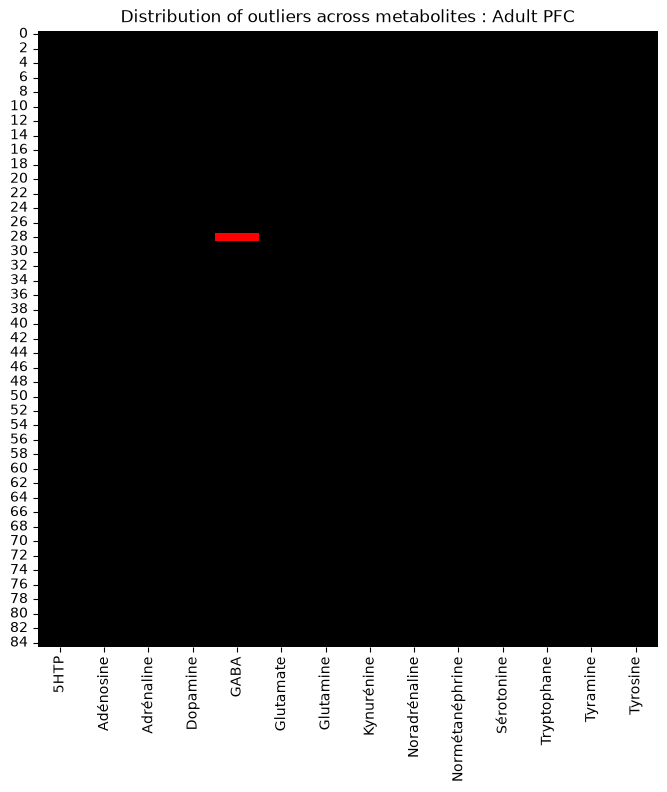

In [10]:

nts = [
    "5HTP",
    "Adénosine",
    "Adrénaline",
    "Dopamine",
    "GABA",
    "Glutamate",
    "Glutamine",
    "Kynurénine",
    "Noradrénaline",
    "Normétanéphrine",
    "Sérotonine",
    "Tryptophane",
    "Tyramine",
    "Tyrosine"
] # List of neurotransmitters to visualize the distribution of outliers

plt.figure(figsize=(8, 8))
sns.heatmap(
    outlier_mask[nts],
    linewidths=0,
    cmap=["black", "red"],
    cbar=False
) # Create a heatmap to visualize the distribution of outliers across the selected neurotransmitters. The heatmap will show black for non-outlier values and red for outlier values, allowing us to easily identify which neurotransmitters have outlier values in the dataset.
plt.title("Distribution of outliers across metabolites : Adult PFC")
plt.show()

<span style="font-weight: bold;">
 For more information about that outlier  </span>

In [11]:
print(df.loc[mask])

   Projet     Cohort Group  Cage  ID  ID.2  Sample Name     Sex Area  \
28  VEAVE  Cohorte 3  CONT    18 NaN  18-1          NaN  female  PFC   

   Sample Name.1  ...   GABA  Glutamate  Glutamine  Kynurénine  Noradrénaline  \
28         18-1_  ...  21.63      7.197     0.5289    0.002358           2.49   

    Normétanéphrine  Sérotonine  Tryptophane  Tyramine  Tyrosine  
28            6.567     0.09077       0.9024   0.01267     4.856  

[1 rows x 24 columns]


<span style="font-weight: bold;">
 Now we remove that value, so that it will not affect the analysis. </span>

In [12]:
df = df[
    ~(
        (df['GABA'] > 21)
    )
]
df = df.reset_index(drop=True) # Reset the index of the dataframe since we removed a row

<span style="font-weight: bold;"> Now we homogenize the the values of the Sex columns (ex : Male, male, Female, female) </span>

In [13]:
df["Sex"] = df["Sex"].str.lower() # So now there is now only lowercase values in the "Sex" column

<span style="font-weight: bold;"> So the different columns are : </span>

In [14]:
print(f"The columns in the dataset are: {df.columns}")

The columns in the dataset are: Index(['Projet', 'Cohort', 'Group', 'Cage', 'ID', 'ID.2', 'Sample Name', 'Sex',
       'Area', 'Sample Name.1', '5HTP', 'Adénosine', 'Adrénaline', 'Dopamine',
       'GABA', 'Glutamate', 'Glutamine', 'Kynurénine', 'Noradrénaline',
       'Normétanéphrine', 'Sérotonine', 'Tryptophane', 'Tyramine', 'Tyrosine'],
      dtype='str')


### Separation of the Data by Area

<span style="font-weight: bold;"> Here we separate the data into 2 dataset : For the PFC, HIP</span>

In [15]:
NT_df_pfc_adu = df.query("Area == 'PFC'").copy() # Create a copy of the DataFrame for the PFC area
NT_df_hip_adu = df.query("Area == 'HIP'").copy() # Create a copy of the DataFrame for the HIP area

<span style="font-weight: bold;"> Now, for the number of individuals in each group for each Area. </span>

In [16]:
print(f" --In the PFC group--:",NT_df_pfc_adu['Group'].value_counts()) # Print the count of each group in the PFC area
print(f" --In the HIP group-- :",NT_df_hip_adu['Group'].value_counts()) # Print the count of each group in the HIP area

 --In the PFC group--: Group
LBN     25
CONT    17
Name: count, dtype: int64
 --In the HIP group-- : Group
LBN     25
CONT    17
Name: count, dtype: int64


<span style="font-weight: bold;"> Now, the count of individuals broken down by sex cohort and cage, per area. </span>

#### For the PFC 

In [17]:
from tabulate import tabulate

pfc_summary = (
    NT_df_pfc_adu
    .groupby(["Group", "Sex", "Cohort", "Cage"], dropna=False)
    .size()
    .reset_index(name="N")
    .sort_values(["Group", "Sex", "Cohort", "Cage"])
)

print("\nPFC Area\n")
print(
    tabulate(
        pfc_summary,
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)


PFC Area

╒═════════╤════════╤═══════════╤════════╤═════╕
│ Group   │ Sex    │ Cohort    │   Cage │   N │
╞═════════╪════════╪═══════════╪════════╪═════╡
│ CONT    │ female │ Cohorte 3 │     14 │   3 │
├─────────┼────────┼───────────┼────────┼─────┤
│ CONT    │ female │ Cohorte 3 │     17 │   4 │
├─────────┼────────┼───────────┼────────┼─────┤
│ CONT    │ female │ Cohorte 3 │     18 │   3 │
├─────────┼────────┼───────────┼────────┼─────┤
│ CONT    │ male   │ Cohorte 3 │     13 │   2 │
├─────────┼────────┼───────────┼────────┼─────┤
│ CONT    │ male   │ Cohorte 3 │     19 │   5 │
├─────────┼────────┼───────────┼────────┼─────┤
│ LBN     │ female │ Cohorte 3 │     12 │   3 │
├─────────┼────────┼───────────┼────────┼─────┤
│ LBN     │ female │ Cohorte 3 │     16 │   3 │
├─────────┼────────┼───────────┼────────┼─────┤
│ LBN     │ female │ Cohorte 3 │     20 │   2 │
├─────────┼────────┼───────────┼────────┼─────┤
│ LBN     │ male   │ Cohorte 3 │     10 │   5 │
├─────────┼────────┼─────────

#### For the HIP

In [18]:
from tabulate import tabulate

pfc_summary = (
    NT_df_hip_adu
    .groupby(["Group", "Sex", "Cohort", "Cage"], dropna=False)
    .size()
    .reset_index(name="N")
    .sort_values(["Group", "Sex", "Cohort", "Cage"])
)

print("\nHIP Area\n")
print(
    tabulate(
        pfc_summary,
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)


HIP Area

╒═════════╤════════╤═══════════╤════════╤═════╕
│ Group   │ Sex    │ Cohort    │   Cage │   N │
╞═════════╪════════╪═══════════╪════════╪═════╡
│ CONT    │ female │ Cohorte 3 │     14 │   2 │
├─────────┼────────┼───────────┼────────┼─────┤
│ CONT    │ female │ Cohorte 3 │     17 │   4 │
├─────────┼────────┼───────────┼────────┼─────┤
│ CONT    │ female │ Cohorte 3 │     18 │   4 │
├─────────┼────────┼───────────┼────────┼─────┤
│ CONT    │ male   │ Cohorte 3 │     13 │   2 │
├─────────┼────────┼───────────┼────────┼─────┤
│ CONT    │ male   │ Cohorte 3 │     19 │   5 │
├─────────┼────────┼───────────┼────────┼─────┤
│ LBN     │ female │ Cohorte 3 │     12 │   3 │
├─────────┼────────┼───────────┼────────┼─────┤
│ LBN     │ female │ Cohorte 3 │     16 │   3 │
├─────────┼────────┼───────────┼────────┼─────┤
│ LBN     │ female │ Cohorte 3 │     20 │   2 │
├─────────┼────────┼───────────┼────────┼─────┤
│ LBN     │ male   │ Cohorte 3 │     10 │   5 │
├─────────┼────────┼─────────

In [19]:
print("\nFor the HIP Area :")
print(
    NT_df_hip_adu
    .groupby(['Group', 'Sex', 'Cohort', 'Cage'], dropna=False)
    .size()
    .reset_index(name='N')
) # Print the count of each group in the HIP area, grouped by "Group", "Sex", "Cohort", and "Cage". This will help us understand the distribution of samples across different groups and conditions in the HIP area.    


For the HIP Area :
   Group     Sex     Cohort  Cage  N
0   CONT  female  Cohorte 3    14  2
1   CONT  female  Cohorte 3    17  4
2   CONT  female  Cohorte 3    18  4
3   CONT    male  Cohorte 3    13  2
4   CONT    male  Cohorte 3    19  5
5    LBN  female  Cohorte 3    12  3
6    LBN  female  Cohorte 3    16  3
7    LBN  female  Cohorte 3    20  2
8    LBN    male  Cohorte 3    10  5
9    LBN    male  Cohorte 3    11  5
10   LBN    male  Cohorte 3    15  3
11   LBN    male  Cohorte 3    21  4


### Separation of the Data into 2 Dataset : X (Predictors : Variables - NTS ) and Y (Outcome : Group - LBN vs CONT)

In [20]:
columns_to_drop = ['Projet', 'Cohort', 'Group', 'Cage', 'ID', 'ID.2', 'Sample Name', 'Sex','Area', 'Sample Name.1','Adrénaline'] # List of columns to drop from the DataFrame before creating the feature matrix (X : Neurotransmitters) and target vector (Y : Group) for machine learning models. These columns are not relevant for the analysis and will be removed to focus on the neurotransmitter data.
X_adu_pfc = NT_df_pfc_adu.drop(columns=columns_to_drop) # This will leave us with only the neurotransmitter data that we want to use for machine learning models.
Y_adu_pfc = NT_df_pfc_adu['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int) # Convert the 'Group' column to integers (0 for 'CONT', 1 for 'LBN')
X_adu_hip = NT_df_hip_adu.drop(columns=columns_to_drop) # This will leave us with only the neurotransmitter data that we want to use for machine learning models.
Y_adu_hip = NT_df_hip_adu['Group'].replace({'CONT': 0, 'LBN': 1}).astype(int) # Convert the 'Group' column to integers (0 for 'CONT', 1 for 'LBN')

### Visualisation of the missing values.

<span style="font-weight: bold;"> Here's a representation of these missing values </span>

--- 

#### For the PFC

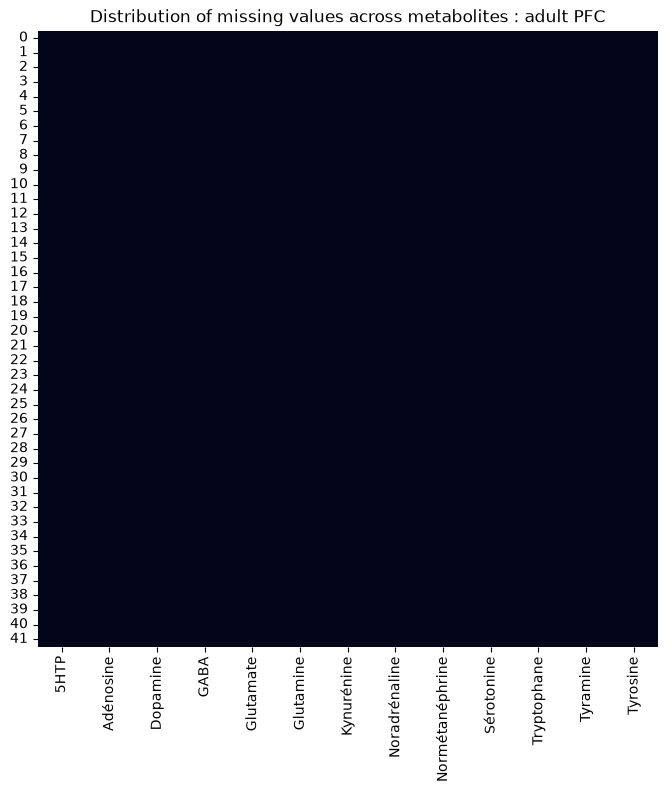

In [21]:
plt.figure(figsize=(8, 8))
sns.heatmap(X_adu_pfc.isna(), cbar=False)
plt.title("Distribution of missing values across metabolites : adult PFC")
plt.show()

<span style="font-weight: bold;"> So we can observe that there is no missing values for in the PFC region </span>

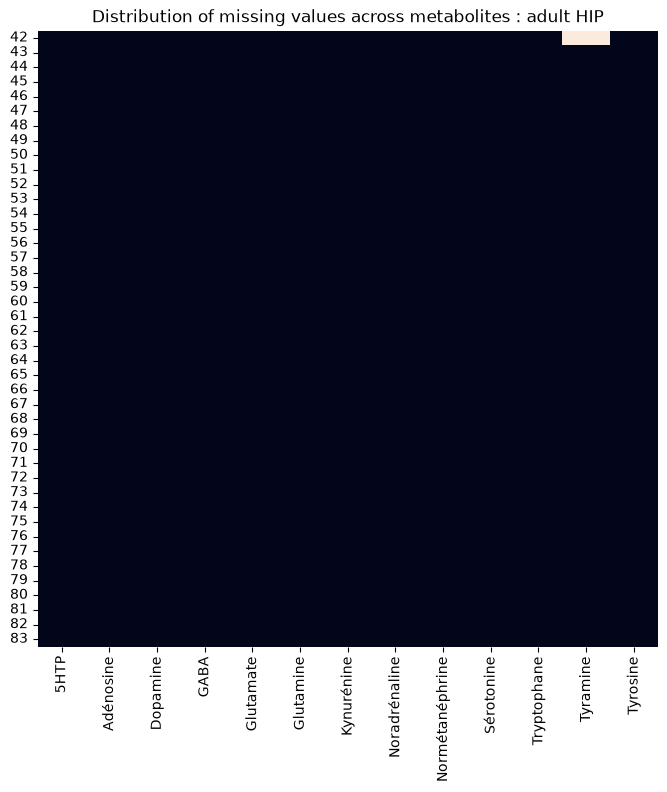

In [22]:
plt.figure(figsize=(8, 8))
sns.heatmap(X_adu_hip.isna(), cbar=False)
plt.title("Distribution of missing values across metabolites : adult HIP")
plt.show()

<span style="font-weight: bold;"> So we can observe that there is a missing values in the HIP region </span>

In [23]:
print("Information about the samples who have a missing value : HIP adu")
print(X_adu_hip[X_adu_hip.isna().any(axis=1)].to_markdown())

Information about the samples who have a missing value : HIP adu
|    |     5HTP |   Adénosine |   Dopamine |   GABA |   Glutamate |   Glutamine |   Kynurénine |   Noradrénaline |   Normétanéphrine |   Sérotonine |   Tryptophane |   Tyramine |   Tyrosine |
|---:|---------:|------------:|-----------:|-------:|------------:|------------:|-------------:|----------------:|------------------:|-------------:|--------------:|-----------:|-----------:|
| 42 | 0.004735 |       2.906 |   0.008253 |  10.28 |       5.128 |      0.3542 |     0.001646 |           4.656 |             2.168 |      0.05363 |        0.5051 |        nan |      1.255 |


<span style="font-weight: bold;">Now we will remove those missing values  </span>

In [24]:
X_adu_hip = X_adu_hip.dropna() # Remove any rows with missing values
Y_adu_hip = Y_adu_hip.loc[X_adu_hip.index] # Keep only the target values corresponding to the remaining samples

<span style="font-weight: bold;">Now we will create a copy of the adult HIP dataset and add experimental groups ("CONT" and "LBN")</span>

In [25]:
X_adu_hip_with_group = X_adu_hip.copy() # Create a copy of the X_adu_hip DataFrame to add the "Group" column for better visualization and analysis. This will allow us to see the group labels alongside the neurotransmitter data, making it easier to interpret the results of our analyses.
X_adu_hip_with_group["Group"] = Y_adu_hip.map({0: "CONT", 1: "LBN"}) 
X_adu_hip_with_group.head()

,5HTP,Adénosine,Dopamine,GABA,Glutamate,Glutamine,Kynurénine,Noradrénaline,Normétanéphrine,Sérotonine,Tryptophane,Tyramine,Tyrosine,Group
43,0.006164,2.061,0.02503,9.491,5.310,0.3109,0.001261,5.350,1.933,0.02437,0.4335,0.010230,2.562,LBN
44,0.007627,1.634,0.09494,10.810,5.807,0.3432,0.001761,5.174,2.389,0.04958,0.3639,0.009419,2.629,LBN
45,0.005829,2.227,0.01250,8.795,4.757,0.3372,0.001693,4.648,1.942,0.04299,0.5612,0.001611,2.165,LBN
46,0.004582,2.186,0.01300,7.942,4.537,0.2883,0.001235,4.201,2.045,0.04893,0.3784,0.010940,2.691,LBN
47,0.004421,3.798,0.01182,8.889,3.752,0.3312,0.001452,4.025,2.570,0.02309,0.5216,0.004784,2.597,LBN


#### Transformation Log 

<span style="font-weight: bold;">Apply a log(1+x) transformation to reduce skewness</span>


In [26]:
X_adu_pfc_log = np.log1p(X_adu_pfc) # Apply a log transformation to the PFC neurotransmitter data to reduce skewness and make the data more normally distributed. This can help improve the performance of machine learning models that assume normally distributed data.
X_adu_hip_log = np.log1p(X_adu_hip) # Apply a log transformation to the HIP neurotransmitter data to reduce skewness and make the data more normally distributed. This can help improve the performance of machine learning models that assume normally distributed data.

## Analysis

### Principal Component Analysis (PCA)


---

#### For the PFC

<span style="font-weight: bold;"> A z-score normalization was used to center and scale all features prior to analysis.

In [27]:
scaler = StandardScaler() # Create a StandardScaler object to standardize the features by removing the mean and scaling to unit variance. This is important for many machine learning algorithms that are sensitive to the scale of the input features. 
X_adu_pfc_scaled = scaler.fit_transform(X_adu_pfc_log) # Standardize the log-transformed PFC neurotransmitter data

<span style="font-weight: bold;">  Here we apply PCA to the standardized PFC dataset and retain the first 10 principal components to know more about the explained variance

In [28]:
from sklearn.decomposition import PCA
pca1 = PCA(n_components=10) # Create a PCA object to reduce the dimensionality of the PFC neurotransmitter data to 10 principal components.
X_adu_pfc_pca_all = pca1.fit_transform(X_adu_pfc_scaled) # Apply the PCA transformation to the scaled PFC neurotransmitter data.

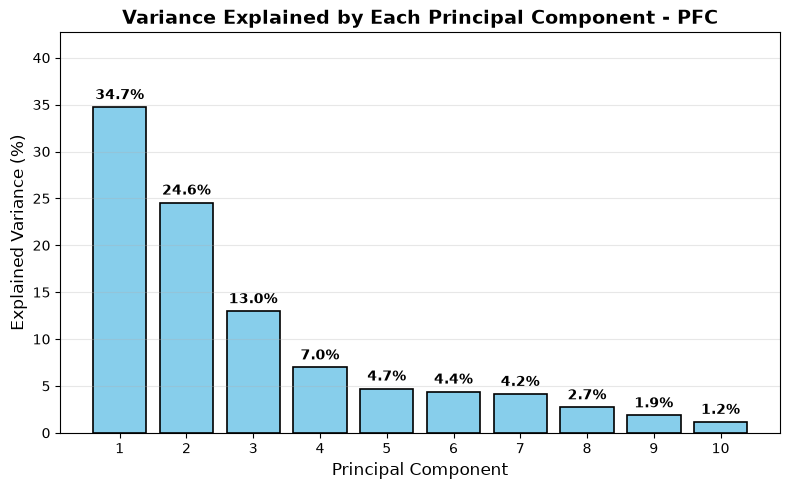

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Percentage of explained variance
explained = pca1.explained_variance_ratio_ * 100

# Create figure
plt.figure(figsize=(8, 5))

# Bar plot
bars = plt.bar(
    range(1, len(explained) + 1),
    explained,
    color="skyblue",
    edgecolor="black",
    linewidth=1.2
)

# Add percentage labels with black outline
for bar, value in zip(bars, explained):

    txt = plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# Labels and title
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Explained Variance (%)", fontsize=12)
plt.title(
    "Variance Explained by Each Principal Component - PFC",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(range(1, len(explained) + 1))
plt.ylim(0, max(explained) + 8)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [30]:
import pandas as pd
import numpy as np

# Individual and cumulative explained variance
explained = pca1.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

# Create table
variance_table = pd.DataFrame({
    "Principal Component": [f"PC{i}" for i in range(1, len(explained) + 1)],
    "Explained Variance (%)": explained,
    "Cumulative Variance (%)": cumulative
})

# Pretty display
variance_table.style \
    .format({
        "Explained Variance (%)": "{:.2f}",
        "Cumulative Variance (%)": "{:.2f}"
    }) \
    .hide(axis="index") \
    .set_caption("Explained Variance by Principal Component") \
    .background_gradient(
        subset=["Explained Variance (%)"],
        cmap="Blues"
    ) \
    .background_gradient(
        subset=["Cumulative Variance (%)"],
        cmap="Greens"
    )

Principal Component,Explained Variance (%),Cumulative Variance (%)
PC1,34.73,34.73
PC2,24.56,59.29
PC3,12.97,72.26
PC4,6.97,79.24
PC5,4.72,83.96
PC6,4.40,88.35
PC7,4.15,92.50
PC8,2.72,95.23
PC9,1.87,97.09
PC10,1.17,98.26


<span style="font-weight: bold;"> Now to know how many Principal Components we need to obtain at least 80% of explained variance.

In [31]:
import numpy as np

for i in range(1, len(pca1.explained_variance_ratio_) + 1):
    x = np.sum(pca1.explained_variance_ratio_[:i])

    if x >= 0.8:
        print(f"To obtain at least 80% of the explained variance, {i} principal components are required which sum up to {x*100:.2f}%.")
        break

To obtain at least 80% of the explained variance, 5 principal components are required which sum up to 83.96%.


<span style="font-weight: bold;">Here we apply PCA to the standardized PFC dataset and retain the first 3 principal components for our analysis

In [32]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_adu_pfc_pca = pca.fit_transform(X_adu_pfc_scaled)

In [33]:
print(f"The value of the PCA: \n PCA1 : {pca1.explained_variance_ratio_[0]},\n PCA2 : {pca1.explained_variance_ratio_[1]} \n PCA3 : {pca1.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

The value of the PCA: 
 PCA1 : 0.3473407151043496,
 PCA2 : 0.24555819612769075 
 PCA3 : 0.1297093373728463 
And the sum is: 0.7226082486048867


<span style="font-weight: bold;"> Now to have a visualtion of the PCA projection of PFC samples on the first two principal components

findfont: Failed to find font weight semibold, now using 700.


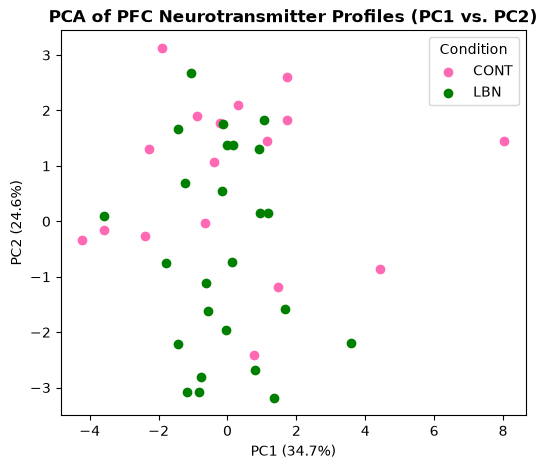

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_adu_pfc_pca[Y_adu_pfc == 0, 0],
    X_adu_pfc_pca[Y_adu_pfc == 0, 1],
    label="CONT",
    color="hotpink"
)

plt.scatter(
    X_adu_pfc_pca[Y_adu_pfc == 1, 0],
    X_adu_pfc_pca[Y_adu_pfc == 1, 1],
    label="LBN",
    color="green"
)

plt.title("PCA of PFC Neurotransmitter Profiles (PC1 vs. PC2)", fontweight='semibold')

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend(title="Condition")
plt.show()

<span style="font-weight: bold;"> Create a 3D PCA score plot with projection ("needle") lines extending from each sample to the base plane to facilitate the visualization of sample positions in three-dimensional space.

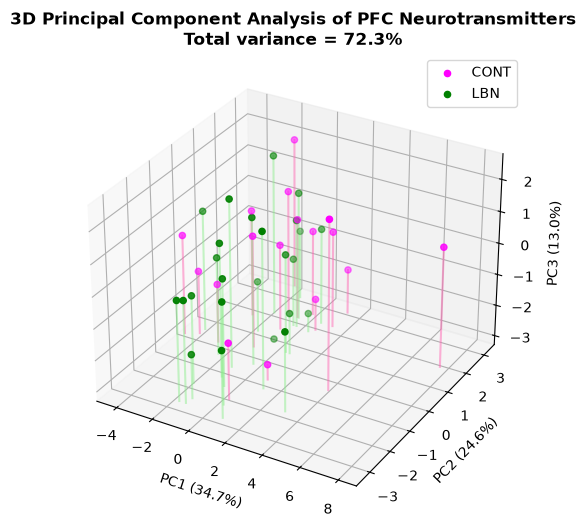

In [35]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

zmin = X_adu_pfc_pca[:,2].min() # here we define the minimum value of the z-axis to be used for the needle lines. This is set to the minimum value of the third principal component (PC3) in the PCA-transformed data.

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_adu_pfc_pca[Y_adu_pfc==0, :3]:
     ax.plot([x, x], [y, y], [zmin, z], color='hotpink', alpha=0.5)

ax.scatter(
    X_adu_pfc_pca[Y_adu_pfc==0,0],
    X_adu_pfc_pca[Y_adu_pfc==0,1],
    X_adu_pfc_pca[Y_adu_pfc==0,2],
    label="CONT",
    color='magenta'
)

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_adu_pfc_pca[Y_adu_pfc==1, :3]:
    ax.plot([x, x], [y, y], [zmin, z], color='lightgreen', alpha=0.5)

ax.scatter(
    X_adu_pfc_pca[Y_adu_pfc==1,0],
    X_adu_pfc_pca[Y_adu_pfc==1,1],
    X_adu_pfc_pca[Y_adu_pfc==1,2],
    label="LBN",
    color='green'
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"3D Principal Component Analysis of PFC Neurotransmitters\n"
    f"Total variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%",
    fontweight='semibold'
)

ax.legend()
plt.show()

<span style="font-weight: bold;"> Now we will create a PCA score plot of the PFC neurotransmitter data to visualize the distribution of samples from the CONT and LBN groups along the first three principal components.

findfont: Failed to find font weight semibold, now using 700.


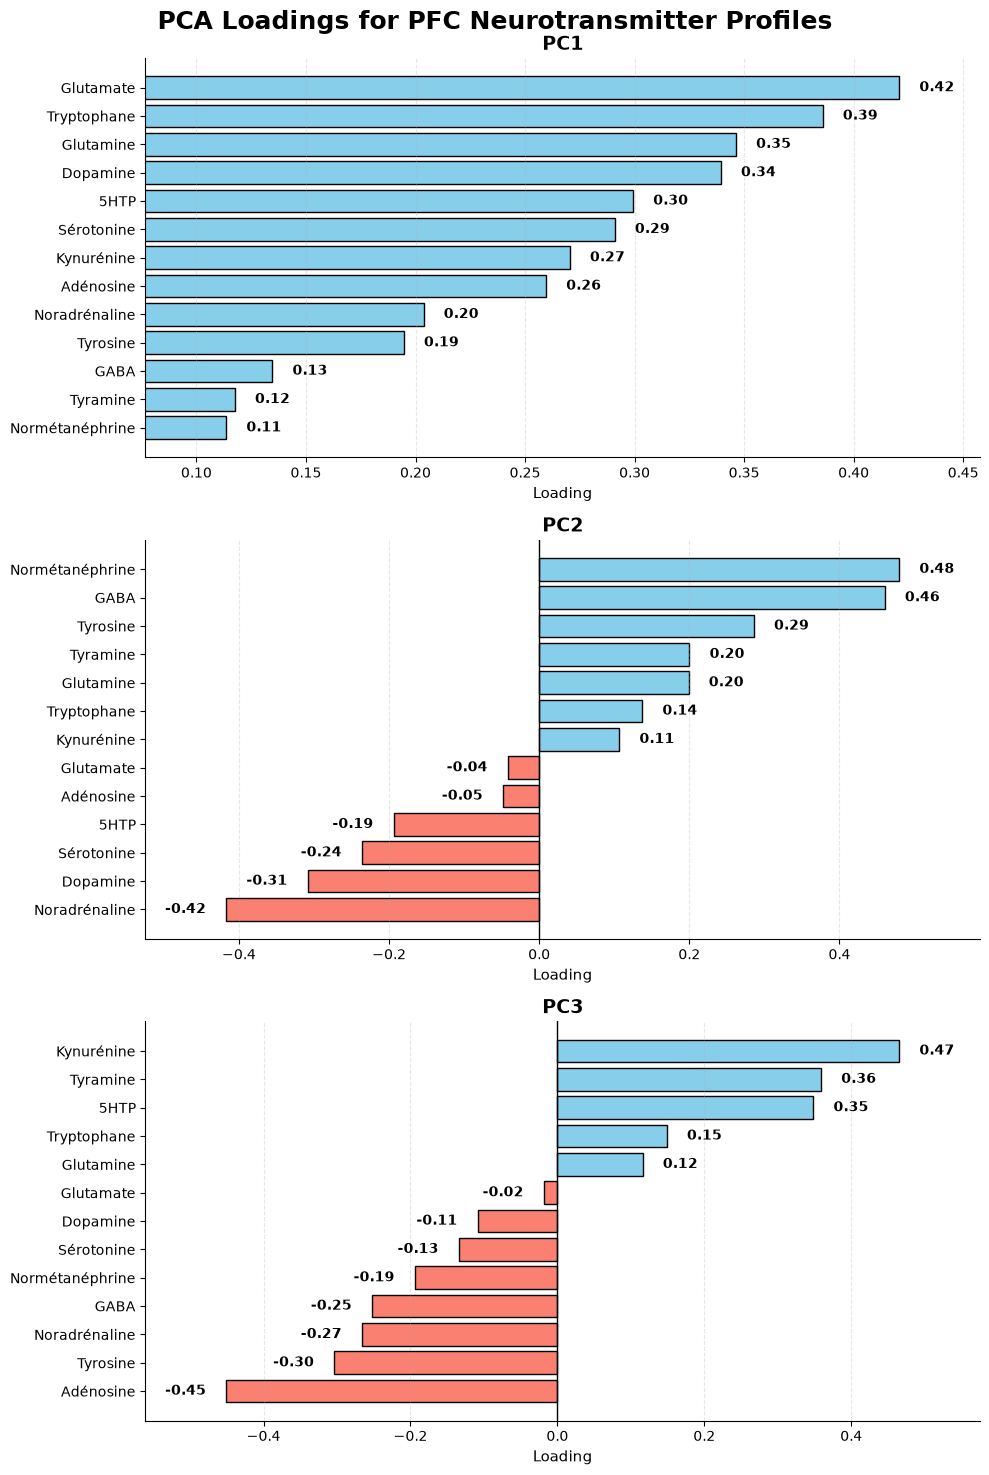

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# PCA loadings
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_adu_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

fig.suptitle(
    "PCA Loadings for PFC Neurotransmitter Profiles",fontsize=18, fontweight="semibold"
)

for i, pc in enumerate(loadings_pfc.columns):
    ax = axes[i]
    values = loadings_pfc[pc].sort_values()
    colors = [ "skyblue" if v >= 0 else "salmon" for v in values]

    bars = ax.barh(
        values.index,
        values.values,
        color=colors,
        edgecolor="black"
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(
        pc,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Loading",
        fontsize=11
    )

    xmin = values.min()
    xmax = values.max()
    offset = (xmax - xmin) * 0.03

    ax.set_xlim(xmin - 4*offset, xmax + 4*offset)

    for bar, value in zip(bars, values):

        if value >= 0:
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="left",
                fontsize=10,
                fontweight="bold"
            )
        else:
            ax.text(
                value - offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="right",
                fontsize=10,
                fontweight="bold"
            )

plt.tight_layout()
plt.show()

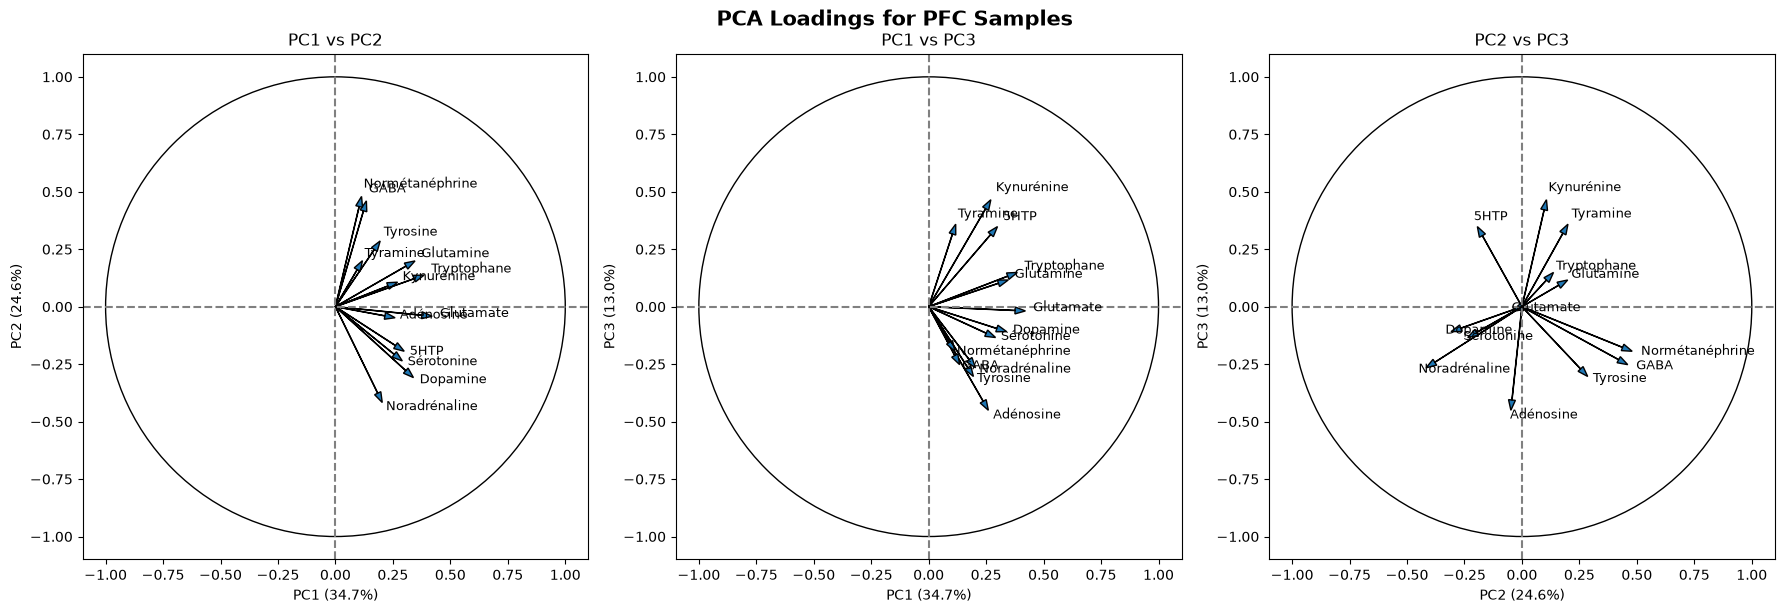

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_pfc = pd.DataFrame(
    pca.components_.T,
    index=X_adu_pfc.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for PFC Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_pfc.index:

        x = loadings_pfc.loc[nt, pcx]
        y = loadings_pfc.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

---

#### For the HIP 

In [38]:
scaler = StandardScaler()
X_adu_hip_scaled = scaler.fit_transform(X_adu_hip_log)

In [39]:
from sklearn.decomposition import PCA
pca1 = PCA(n_components=10)
X_adu_hip_scaled1 = X_adu_hip_scaled.copy()
X_adu_hip_pca_all = pca1.fit_transform(X_adu_hip_scaled1)

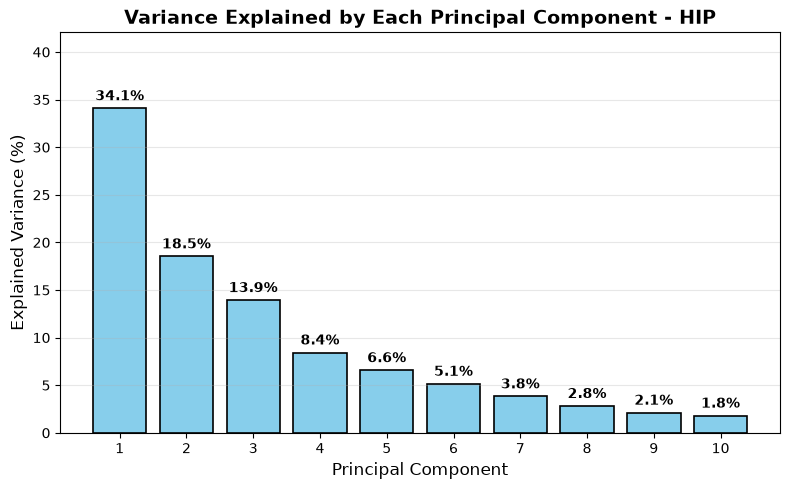

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Percentage of explained variance
explained = pca1.explained_variance_ratio_ * 100

# Create figure
plt.figure(figsize=(8, 5))

# Bar plot
bars = plt.bar(
    range(1, len(explained) + 1),
    explained,
    color="skyblue",
    edgecolor="black",
    linewidth=1.2
)

# Add percentage labels with black outline
for bar, value in zip(bars, explained):

    txt = plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# Labels and title
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Explained Variance (%)", fontsize=12)
plt.title(
    "Variance Explained by Each Principal Component - HIP",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(range(1, len(explained) + 1))
plt.ylim(0, max(explained) + 8)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [41]:
import numpy as np

for i in range(1, len(pca1.explained_variance_ratio_) + 1):
    x = np.sum(pca1.explained_variance_ratio_[:i])

    if x >= 0.8:
        print(f"To obtain at least 80% of the explained variance, {i} principal components are required which sum up to {x*100:.2f}%.")
        break

To obtain at least 80% of the explained variance, 5 principal components are required which sum up to 81.55%.


In [42]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_adu_hip_pca = pca.fit_transform(X_adu_hip_scaled)

In [43]:
print(f"The value of the PCA: \n PCA1 : {pca.explained_variance_ratio_[0]},\n PCA2 : {pca.explained_variance_ratio_[1]} \n PCA3 : {pca.explained_variance_ratio_[2]} ")
print(f"And the sum is:", pca.explained_variance_ratio_.sum())

The value of the PCA: 
 PCA1 : 0.34091387827498576,
 PCA2 : 0.1853005891938515 
 PCA3 : 0.13933317972161524 
And the sum is: 0.6655476471904525


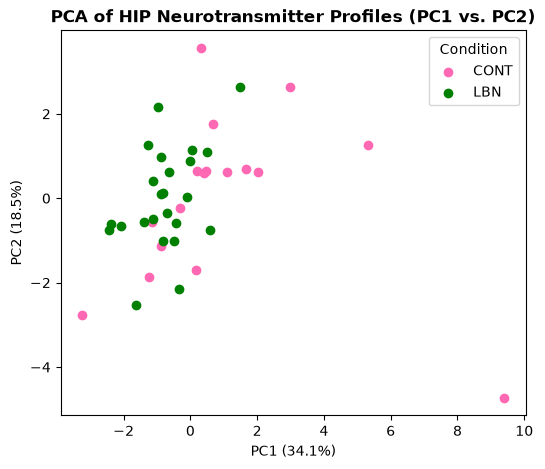

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    X_adu_hip_pca[Y_adu_hip == 0, 0],
    X_adu_hip_pca[Y_adu_hip == 0, 1],
    label="CONT",
    color="hotpink"
)

plt.scatter(
    X_adu_hip_pca[Y_adu_hip == 1, 0],
    X_adu_hip_pca[Y_adu_hip == 1, 1],
    label="LBN",
    color="green"
)

plt.title("PCA of HIP Neurotransmitter Profiles (PC1 vs. PC2)", fontweight='semibold')

plt.xlabel(
    f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
)

plt.legend(title="Condition")
plt.show()

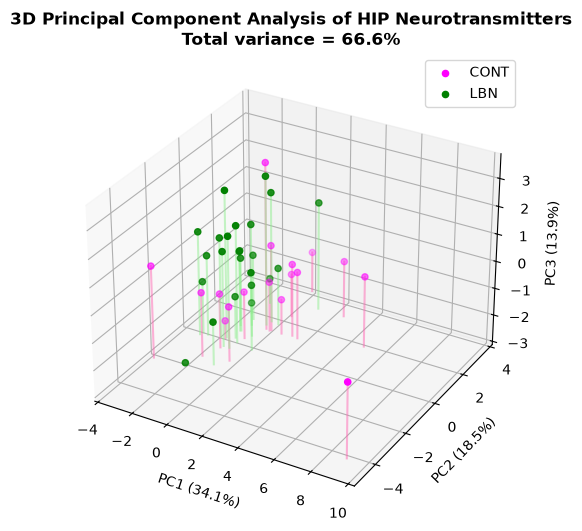

In [45]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

zmin = X_adu_hip_pca[:,2].min() # here we define the minimum value of the z-axis to be used for the needle lines. This is set to the minimum value of the third principal component (PC3) in the PCA-transformed data.

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_adu_hip_pca[Y_adu_hip==0, :3]:
     ax.plot([x, x], [y, y], [zmin, z], color='hotpink', alpha=0.5)

ax.scatter(
    X_adu_hip_pca[Y_adu_hip==0,0],
    X_adu_hip_pca[Y_adu_hip==0,1],
    X_adu_hip_pca[Y_adu_hip==0,2],
    label="CONT",
    color='magenta'
)

# if you don't want the needle lines to the bottom of the plot, you can comment out these two lines
for x, y, z in X_adu_hip_pca[Y_adu_hip==1, :3]:
    ax.plot([x, x], [y, y], [zmin, z], color='lightgreen', alpha=0.5)

ax.scatter(
    X_adu_hip_pca[Y_adu_hip==1,0],
    X_adu_hip_pca[Y_adu_hip==1,1],
    X_adu_hip_pca[Y_adu_hip==1,2],
    label="LBN",
    color='green'
)

ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100*pca.explained_variance_ratio_[2]:.1f}%)")

ax.set_title(
    f"3D Principal Component Analysis of HIP Neurotransmitters\n"
    f"Total variance = {100*sum(pca.explained_variance_ratio_[:3]):.1f}%",
    fontweight='semibold'
)

ax.legend()
plt.show()

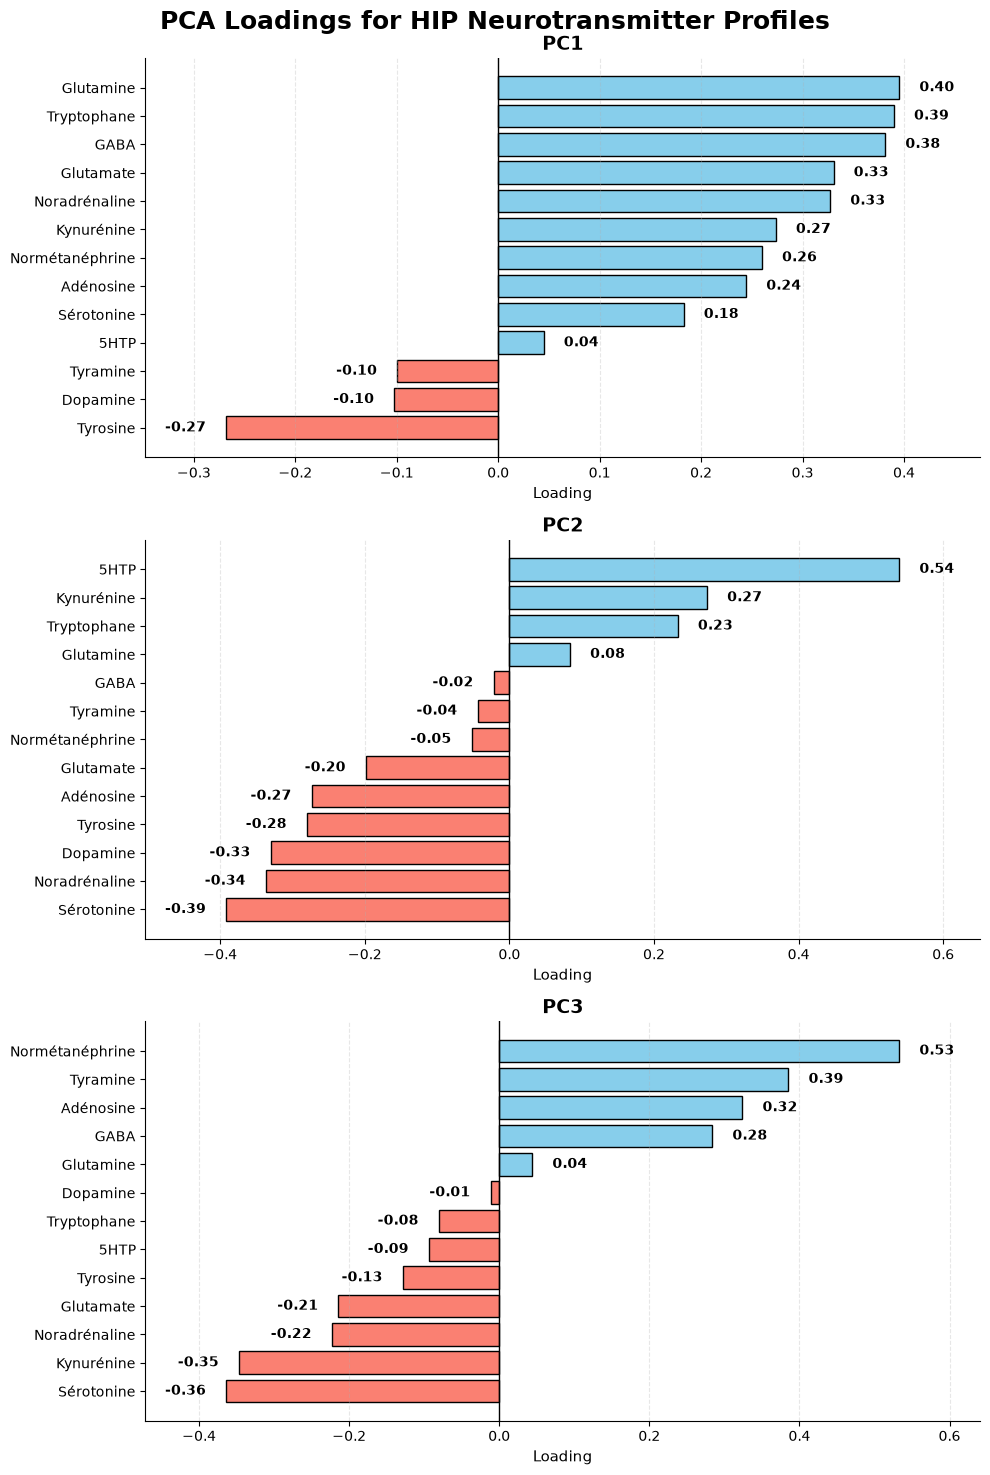

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# PCA loadings
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_adu_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

fig.suptitle(
    "PCA Loadings for HIP Neurotransmitter Profiles",fontsize=18, fontweight="semibold"
)

for i, pc in enumerate(loadings_hip.columns):
    ax = axes[i]
    values = loadings_hip[pc].sort_values()
    colors = [ "skyblue" if v >= 0 else "salmon" for v in values]

    bars = ax.barh(
        values.index,
        values.values,
        color=colors,
        edgecolor="black"
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(
        pc,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Loading",
        fontsize=11
    )

    xmin = values.min()
    xmax = values.max()
    offset = (xmax - xmin) * 0.03

    ax.set_xlim(xmin - 4*offset, xmax + 4*offset)

    for bar, value in zip(bars, values):

        if value >= 0:
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="left",
                fontsize=10,
                fontweight="bold"
            )
        else:
            ax.text(
                value - offset,
                bar.get_y() + bar.get_height()/2,
                f"{value:.2f}",
                va="center",
                ha="right",
                fontsize=10,
                fontweight="bold"
            )

plt.tight_layout()
plt.show()

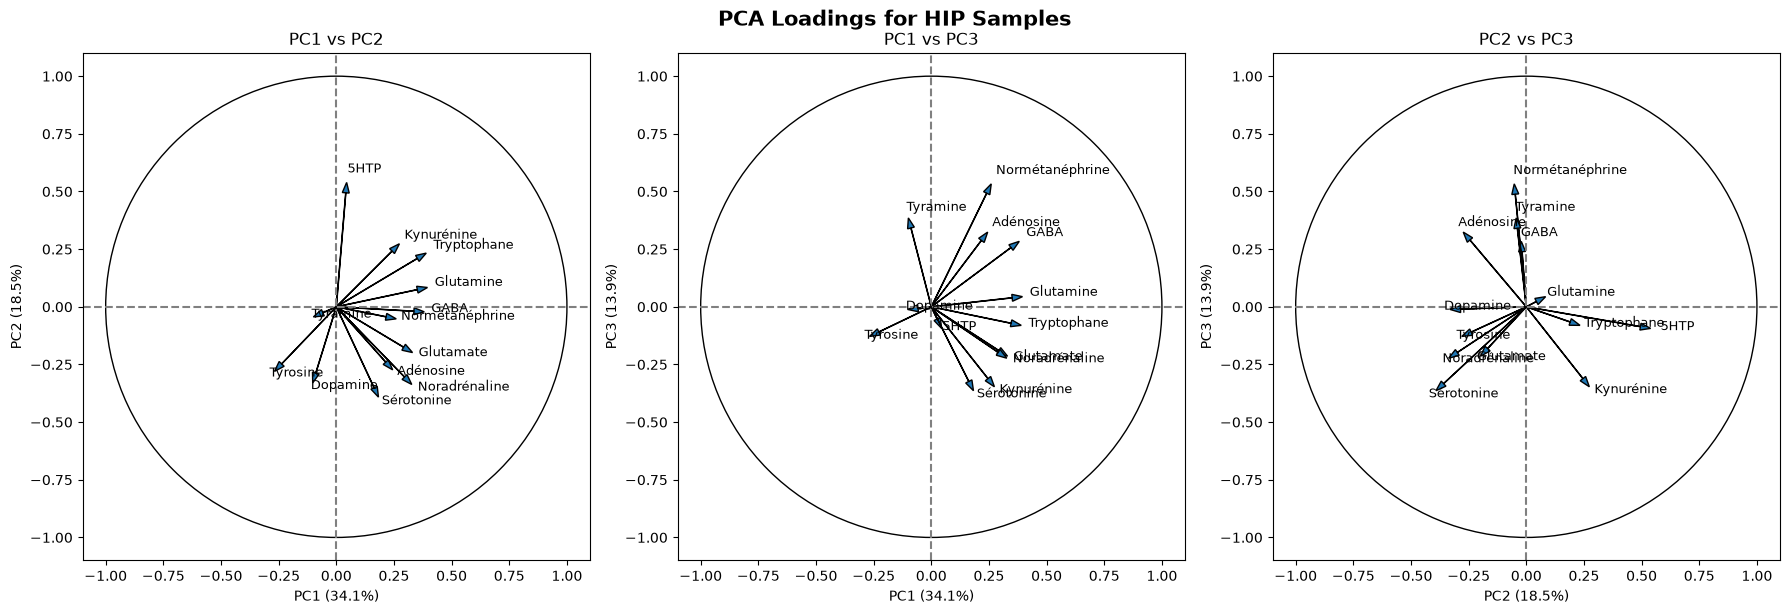

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Loadings
loadings_hip = pd.DataFrame(
    pca.components_.T,
    index=X_adu_hip.columns,
    columns=["PC1", "PC2", "PC3"]
)

pairs = [
    ("PC1", "PC2"),
    ("PC1", "PC3"),
    ("PC2", "PC3")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "PCA Loadings for HIP Samples",
    fontsize=15,
    fontweight="bold"
) 

for ax, (pcx, pcy) in zip(axes, pairs):

    # cercle
    circle = plt.Circle(
        (0, 0),
        1,
        fill=False,
        color="black"
    )
    ax.add_artist(circle)

    # flèches
    for nt in loadings_hip.index:

        x = loadings_hip.loc[nt, pcx]
        y = loadings_hip.loc[nt, pcy]

        ax.arrow(
            0, 0,
            x, y,
            head_width=0.03,
            length_includes_head=True
        )

        ax.text(
            x*1.08,
            y*1.08,
            nt,
            fontsize=9
        )

    ax.axhline(0, color="grey", linestyle="--")
    ax.axvline(0, color="grey", linestyle="--")

    # Pourcentage expliqué
    pcx_num = int(pcx[-1]) - 1
    pcy_num = int(pcy[-1]) - 1

    ax.set_xlabel(
        f"{pcx} ({pca.explained_variance_ratio_[pcx_num]*100:.1f}%)"
    )

    ax.set_ylabel(
        f"{pcy} ({pca.explained_variance_ratio_[pcy_num]*100:.1f}%)"
    )

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")

    ax.set_title(f"{pcx} vs {pcy}")

plt.tight_layout()
plt.show()

### Hierarchical clustering

---

#### For the PFC

<span style="font-weight: bold;"> Hierarchical clustering was performed to explore the similarity between PFC samples based on their standardized neurotransmitter profiles

<span style="font-weight: bold;">Clustering was performed using Ward's linkage and Euclidean distance. Euclidean distance measures the overall dissimilarity between samples. Ward's linkage was chosen because it minimizes the variance within clusters, resulting in compact and well-separated groups.  
<span style="font-weight: bold;">The resulting heatmap visualizes the clustering of samples and neurotransmitters, with a legend indicating the experimental groups (CONT and LBN).

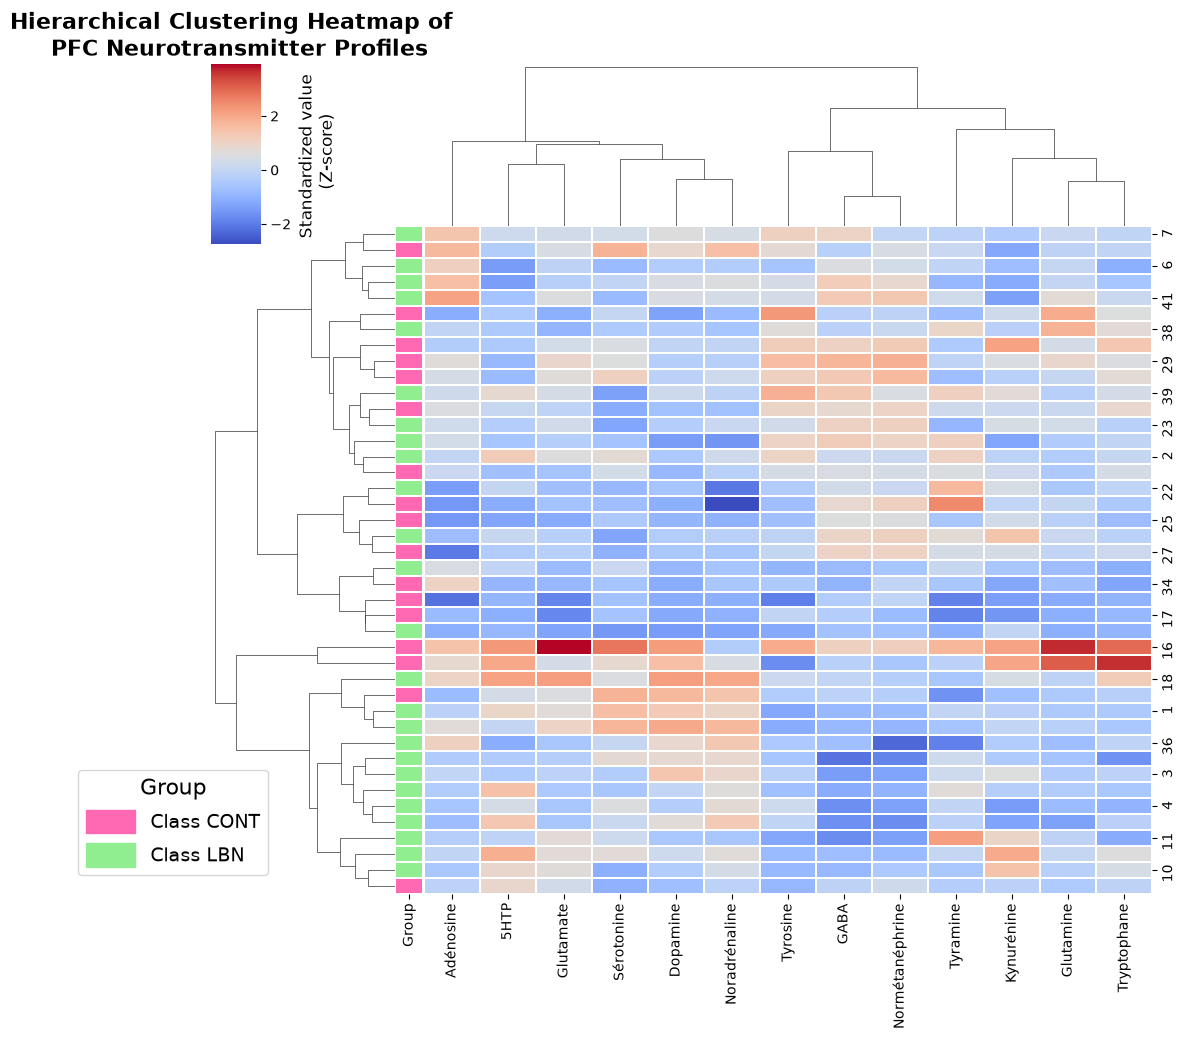

In [48]:
# standardize the data before hierarchical clustering

import matplotlib.patches as mpatches

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_adu_pfc_log)

row_colors = Y_adu_pfc.reset_index(drop=True).map({
    0: "hotpink",
    1: "lightgreen"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_adu_pfc_log.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="hotpink", label="Class CONT"),
    mpatches.Patch(color="lightgreen", label="Class LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering Heatmap of \n PFC Neurotransmitter Profiles", fontsize=16, fontweight="bold")
plt.show()

In [49]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean"
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_adu_pfc.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class CONT", "Class LBN", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class CONT  Class LBN  Total
Cluster                              
1                13         13     26
2                 4         12     16
All              17         25     42


<span style="font-weight: bold;"> Now we will calculate the Silhouette Score to evaluate the quality of the clustering.
The score measures how similar each data point is to its own cluster
compared to the nearest neighboring cluster.

<span style="font-weight: bold;"> Interpretation:

<span style="font-weight: bold;"> -  0.80 – 1.00	Excellent clustering; clusters are highly distinct.

<span style="font-weight: bold;"> - 0.60 – 0.80	Good clustering with clear separation.

<span style="font-weight: bold;"> - 0.40 – 0.60	Reasonable clustering; some overlap may exist.

<span style="font-weight: bold;"> - 0.20 – 0.40	Weak clustering; the groups are not well separated.

<span style="font-weight: bold;"> - < 0.20	Very poor clustering

<span style="font-weight: bold;"> - < 0	Incorrect clustering; many points are likely assigned to the wrong cluster.

 <span style="font-weight: bold;">  In general, a higher Silhouette Score indicates better-defined clusters

In [50]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.19859532342172995


<span style="font-weight: bold;"> So we have a very poor clustering; the groups are not well separated.

---

#### For the HIP

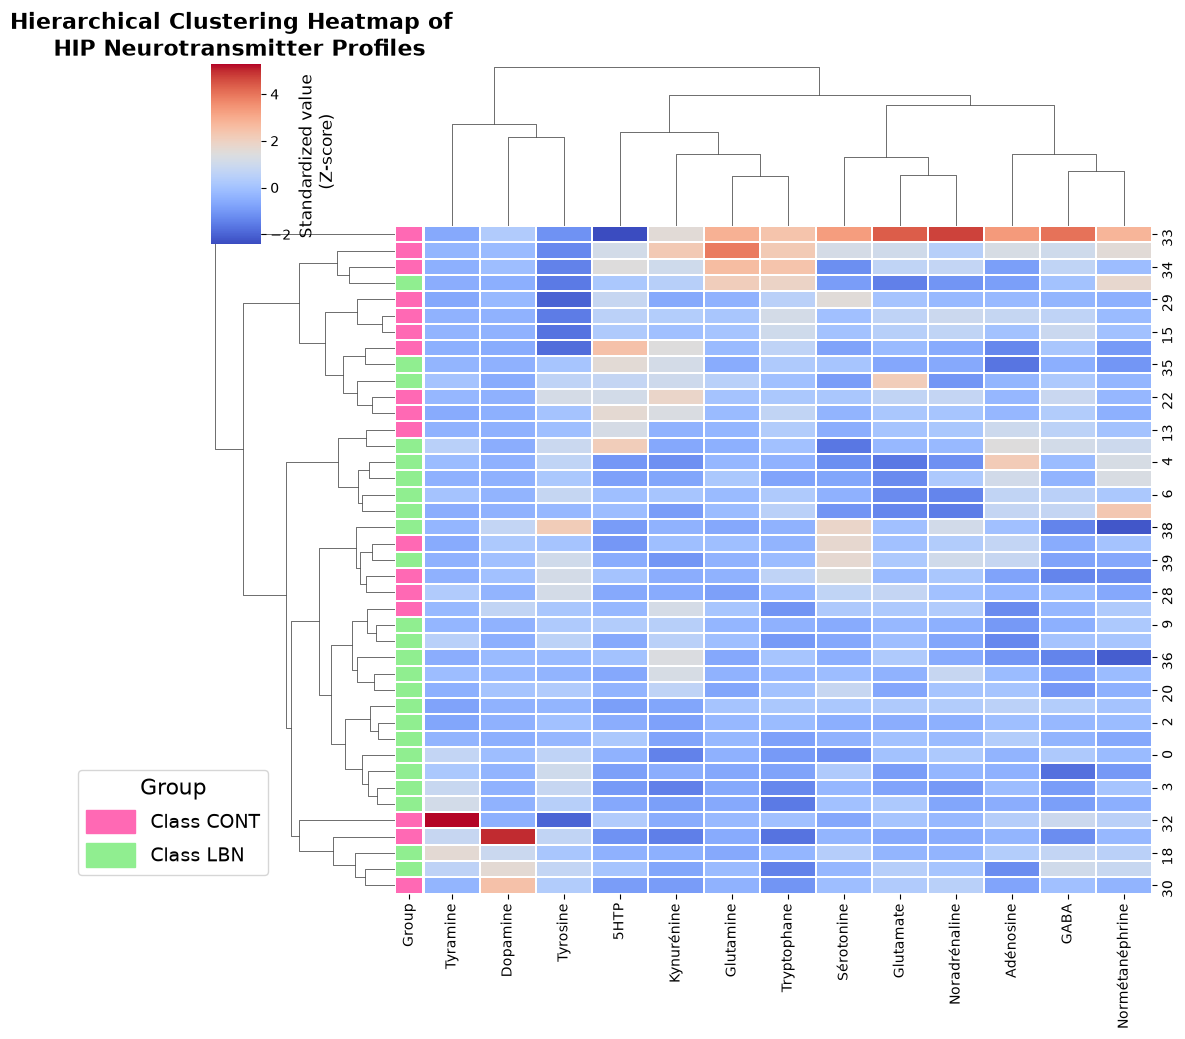

In [51]:
import matplotlib.patches as mpatches

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_adu_hip_log)

row_colors = Y_adu_hip.reset_index(drop=True).map({
    0: "hotpink",
    1: "lightgreen"
})

g = sns.clustermap(
    pd.DataFrame(
        X_scaled,
        columns=X_adu_hip_log.columns
    ),
    method="ward",
    metric="euclidean",
    cmap="coolwarm",
    row_colors=row_colors,
    linewidths=0.2,
    figsize=(10,10)
)

legend_handles = [
    mpatches.Patch(color="hotpink", label="Class CONT"),
    mpatches.Patch(color="lightgreen", label="Class LBN")
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Group",
    loc="upper right",
    bbox_to_anchor=(-0.2, 0.2),
    fontsize=14,        
    title_fontsize=16,  
    handlelength=2.5,  
    handleheight=1.5    
)
g.cax.set_ylabel("Standardized value \n (Z-score)", fontsize=12)
plt.title("Hierarchical Clustering Heatmap of \n HIP Neurotransmitter Profiles", fontsize=16, fontweight="bold")
plt.show()

In [52]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(
    X_scaled,
    method="ward",
    metric="euclidean",
)

clusters = fcluster(
    Z,
    t=2,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "Group": Y_adu_hip.reset_index(drop=True),
    "Cluster": clusters
})

ct = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Group"],
    margins = True
)

ct.columns = ["Class CONT", "Class LBN", "Total"]
ct.index.name = "Cluster"
print(ct)

         Class CONT  Class LBN  Total
Cluster                              
1                16         24     40
2                 1          0      1
All              17         24     41


In [53]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.5907527128485218


<span style="font-weight: bold;"> So we have a weak clustering; the groups are not well separated.

### Logistic Regression

--- 

#### For the PFC

<span style="font-weight: bold;"> Now we will perform a logistic regression analysis to predict the experimental group (CONT vs LBN) based on the standardized neurotransmitter profiles in the PFC dataset.

<span style="font-weight: bold;">Model parameters:  
 <span style="font-weight: bold;">- penalty="l2": Instead of removing variables, L2 regularization penalizes large coefficients by adding a penalty proportional to their squared values during model fitting. This reduces overfitting.  
 <span style="font-weight: bold;">- C=1: default regularization strength. Controls how much the model avoids overfitting; smaller C means a simpler model, while larger C means the model fits the training data more closely.  
 <span style="font-weight: bold;">- class_weight="balanced": compensates for class imbalance by assigning higher weights to the minority class.

 <span style="font-weight: bold;">Model performance is evaluated using repeated stratified 5-fold cross-validation.  
  <span style="font-weight: bold;">- n_splits=5: the dataset is divided into five folds.  
  <span style="font-weight: bold;"> - n_repeats=20: the entire procedure is repeated 20 times with different splits to obtain a more robust estimate of performance.  
 <span style="font-weight: bold;"> - Stratification preserves the class proportions in each fold.



In [54]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_pfc = cross_val_score(
    log_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    scoring="roc_auc"
)

c:\Users\lydia\Downloads\RE_  Multivariate analyses for the NTS\.NTS\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lydia\Downloads\RE_  Multivariate analyses for the NTS\.NTS\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of pen

<span style="font-weight: bold;">Model performance was evaluated using four complementary metrics: accuracy, sensitivity, specificity, and the area under the receiver operating characteristic curve (ROC-AUC). 

<span style="font-weight: bold;"> - Accuracy represents the proportion of correctly classified animals.  
<span style="font-weight: bold;"> - Sensitivity measures the proportion of LBN animals correctly identified by the model.  
<span style="font-weight: bold;"> - Specificity measures the proportion of CONT animals correctly classified.   
<span style="font-weight: bold;"> -  The Receiver Operating Characteristic (ROC) curve evaluates the performance of the classifier across a range of decision thresholds by plotting the true positive rate (sensitivity) against the false positive rate (1 − specificity).   

<span style="font-weight: bold;">The Area Under the ROC Curve (AUC) summarizes the model’s ability to correctly distinguish between positive and negative cases.


In [55]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

===== Logistic Regression =====
Accuracy    = 0.737 ± 0.156
Sensitivity = 0.792 ± 0.185
Specificity = 0.657 ± 0.273
AUC         = 0.808 ± 0.160


 <span style="font-weight: bold;"> The evaluation metric is the Area Under the ROC Curve (ROC-AUC), which measures
 the model's ability to distinguish between the two classes. A ROC-AUC of:  
  <span style="font-weight: bold;"> - 1.0 indicates perfect discrimination.  
 <span style="font-weight: bold;"> - 0.9–1.0 is considered excellent.  
 <span style="font-weight: bold;"> - 0.8–0.9 is considered good.  
 <span style="font-weight: bold;"> - 0.7–0.8 is considered acceptable.  
 <span style="font-weight: bold;"> - 0.5 indicates performance no better than random guessing.  

c:\Users\lydia\Downloads\RE_  Multivariate analyses for the NTS\.NTS\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lydia\Downloads\RE_  Multivariate analyses for the NTS\.NTS\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of pen

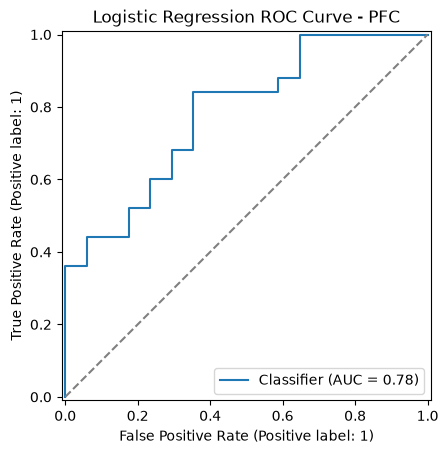

In [56]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_adu_pfc,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - PFC")
plt.show()

In [57]:
log_pipe.fit(X_adu_pfc_log, Y_adu_pfc)

coef = pd.DataFrame({
    "NT": X_adu_pfc_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

c:\Users\lydia\Downloads\RE_  Multivariate analyses for the NTS\.NTS\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


 <span style="font-weight: bold;"> Logistic Regression Coefficients  
The bar plot shows the logistic regression coefficients for each neurotransmitter after model fitting. Positive coefficients (blue) indicate that higher values of the neurotransmitter increase the predicted probability of the LBN class, while negative coefficients (red) indicate an association with the CONT group.

findfont: Failed to find font weight semibold, now using 700.


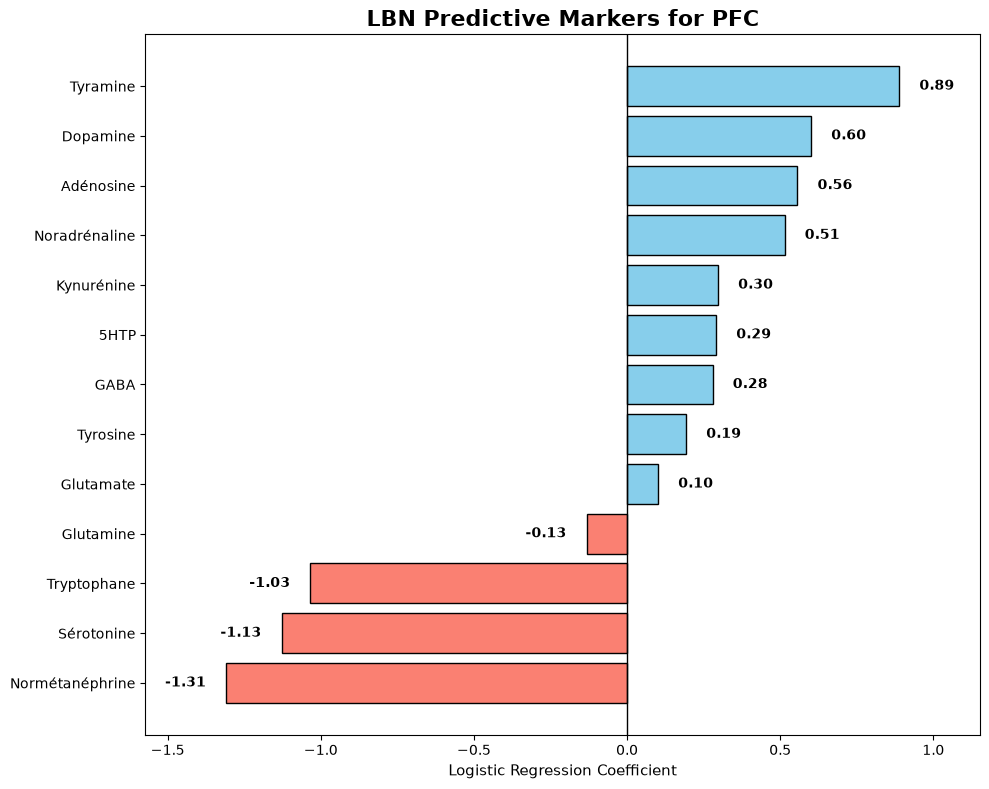

In [58]:
import matplotlib.pyplot as plt

# Sort coefficients
coef = coef.sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(10, 8))

# Color bars by sign
colors = [
    "skyblue" if v >= 0 else "salmon"
    for v in coef["Coefficient"]
]

bars = ax.barh(
    coef["NT"],
    coef["Coefficient"],
    color=colors,
    edgecolor="black"
)

# Reference line at 0
ax.axvline(
    0,
    color="black",
    linewidth=1
)



# Labels and title
ax.set_title(
    "LBN Predictive Markers for PFC",
    fontsize=16,
    fontweight="semibold"
)

ax.set_xlabel(
    "Logistic Regression Coefficient",
    fontsize=11
)

# Add coefficient values
xmin = coef["Coefficient"].min()
xmax = coef["Coefficient"].max()
offset = (xmax - xmin) * 0.03

ax.set_xlim(xmin - 4 * offset, xmax + 4 * offset)

for bar, value in zip(bars, coef["Coefficient"]):

    if value >= 0:
        ax.text(
            value + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )
    else:
        ax.text(
            value - offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="right",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [59]:
print(f"Values of coefficients for PFC:\n{coef.sort_values('Coefficient', ascending=False)}")

Values of coefficients for PFC:
                 NT  Coefficient
11         Tyramine     0.888677
2          Dopamine     0.600837
1         Adénosine     0.556114
7     Noradrénaline     0.514284
6        Kynurénine     0.296921
0              5HTP     0.290796
3              GABA     0.279290
12         Tyrosine     0.192748
4         Glutamate     0.101199
5         Glutamine    -0.131965
10      Tryptophane    -1.033692
9        Sérotonine    -1.127917
8   Normétanéphrine    -1.308687


 <span style="font-weight: bold;">  To evaluate the stability of the logistic regression coefficients, bootstrap resampling is performed using 1,000 iterations. In each iteration, a new dataset is generated by sampling the original observations with replacement, the logistic regression pipeline is refitted, and the resulting coefficients are stored. The distribution of these bootstrap coefficients can then be used to assess the robustness of each feature's estimated effect.

In [60]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_adu_pfc_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_adu_pfc_log,
        Y_adu_pfc,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

c:\Users\lydia\Downloads\RE_  Multivariate analyses for the NTS\.NTS\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lydia\Downloads\RE_  Multivariate analyses for the NTS\.NTS\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of pen

In [61]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

,Mean,Lower95,Upper95
5HTP,0.315993,-0.378231,1.045990
Adénosine,0.583752,-0.199966,1.286500
Dopamine,0.553181,-0.104890,1.244260
GABA,0.122994,-0.700956,0.888294
Glutamate,0.181171,-0.502930,0.855374
Glutamine,-0.171535,-0.900043,0.601214
Kynurénine,0.253681,-0.382003,0.889518
Noradrénaline,0.452172,-0.233661,1.189723
Normétanéphrine,-1.172214,-1.733428,-0.624810
Sérotonine,-1.038671,-1.723872,-0.311478



 <span style="font-weight: bold;"> Bootstrap Results
 The bootstrap analysis estimated the mean logistic regression coefficient and its 95% confidence interval for each neurotransmitter across 1,000 resampled datasets.  
Features whose confidence intervals do not include zero are considered the most stable predictors.  
In this analysis, **Tyramine** showed a consistently positive contribution, while **Normétanéphrine**, **Sérotonine**, and **Tryptophane** showed consistently negative contributions. The 95% confidence intervals for these neurotransmitters did not cross zero

---

#### For the HIP

In [84]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        C=1,
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

log_scores_hip = cross_val_score(
    log_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv,
    scoring="roc_auc"
)

In [86]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score

# Sensitivity = Recall of positive class (LBN = 1)
sensitivity = make_scorer(
    recall_score,
    pos_label=1
)

# Specificity = Recall of negative class (CONT = 0)
specificity = make_scorer(
    recall_score,
    pos_label=0
)

scores = cross_validate(
    log_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "sensitivity": sensitivity,
        "specificity": specificity
    },
    n_jobs=-1
)

print("===== Logistic Regression =====")

print(f"Accuracy    = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

print(f"Sensitivity = {scores['test_sensitivity'].mean():.3f} ± {scores['test_sensitivity'].std():.3f}")

print(f"Specificity = {scores['test_specificity'].mean():.3f} ± {scores['test_specificity'].std():.3f}")

print(f"AUC         = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}")

===== Logistic Regression =====
Accuracy    = 0.641 ± 0.146
Sensitivity = 0.670 ± 0.203
Specificity = 0.602 ± 0.284
AUC         = 0.743 ± 0.159


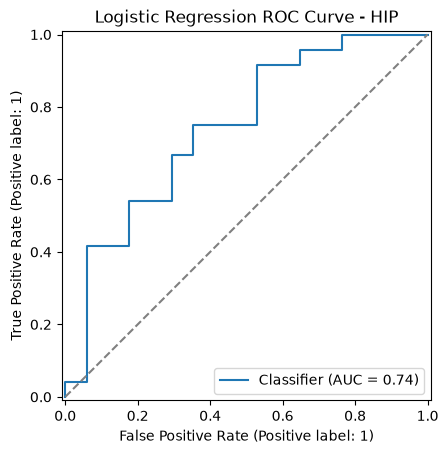

In [87]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    log_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_adu_hip,
    y_prob
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("Logistic Regression ROC Curve - HIP")
plt.show()

In [88]:
log_pipe.fit(X_adu_hip_log, Y_adu_hip)

coef = pd.DataFrame({
    "NT": X_adu_hip_log.columns,
    "Coefficient":
        log_pipe.named_steps["logreg"].coef_[0]
})
coef = coef.sort_values(by="Coefficient", ascending=False)

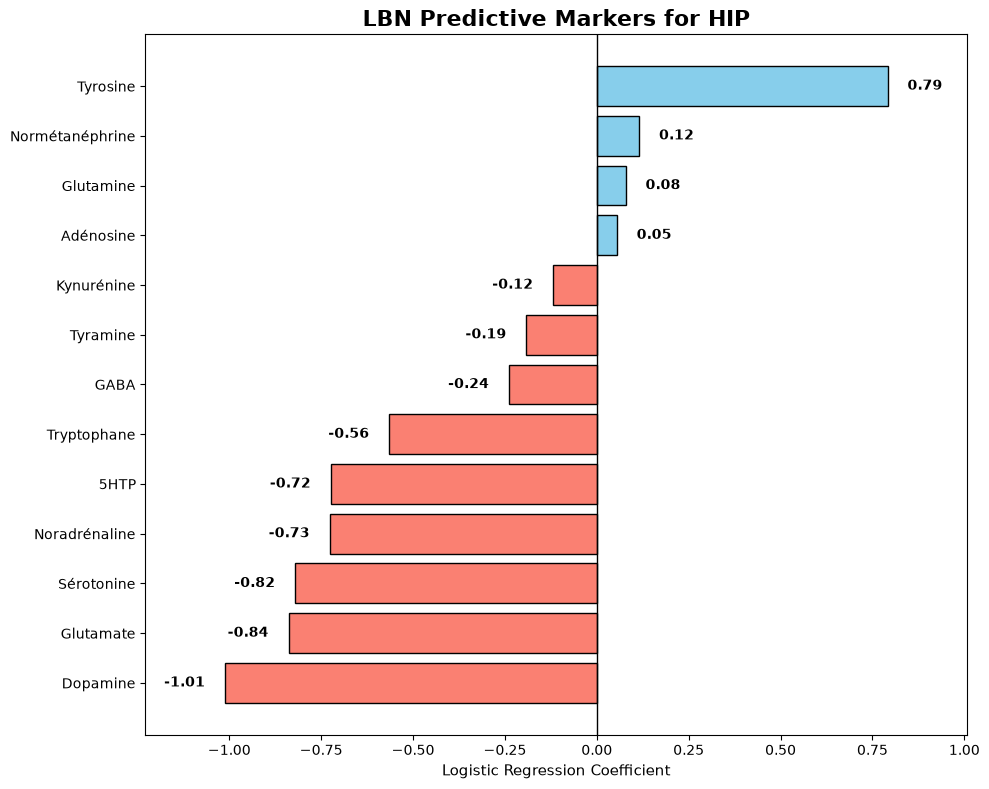

In [89]:
import matplotlib.pyplot as plt

# Sort coefficients
coef = coef.sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(10, 8))

# Color bars by sign
colors = [
    "skyblue" if v >= 0 else "salmon"
    for v in coef["Coefficient"]
]

bars = ax.barh(
    coef["NT"],
    coef["Coefficient"],
    color=colors,
    edgecolor="black"
)

# Reference line at 0
ax.axvline(
    0,
    color="black",
    linewidth=1
)



# Labels and title
ax.set_title(
    "LBN Predictive Markers for HIP",
    fontsize=16,
    fontweight="semibold"
)

ax.set_xlabel(
    "Logistic Regression Coefficient",
    fontsize=11
)

# Add coefficient values
xmin = coef["Coefficient"].min()
xmax = coef["Coefficient"].max()
offset = (xmax - xmin) * 0.03

ax.set_xlim(xmin - 4 * offset, xmax + 4 * offset)

for bar, value in zip(bars, coef["Coefficient"]):

    if value >= 0:
        ax.text(
            value + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )
    else:
        ax.text(
            value - offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="right",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [90]:
print(f"Values of coefficients for HIP:\n{coef.sort_values('Coefficient', ascending=False)}")

Values of coefficients for HIP:
                 NT  Coefficient
12         Tyrosine     0.791252
8   Normétanéphrine     0.115280
5         Glutamine     0.078541
1         Adénosine     0.054460
6        Kynurénine    -0.118939
11         Tyramine    -0.191763
3              GABA    -0.238947
10      Tryptophane    -0.564974
0              5HTP    -0.723969
7     Noradrénaline    -0.727056
9        Sérotonine    -0.820880
4         Glutamate    -0.838745
2          Dopamine    -1.011691


In [91]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

coef_boot = pd.DataFrame(
    columns=X_adu_hip_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_adu_hip_log,
        Y_adu_hip,
        replace=True,
        random_state=i
    )

    # Fit pipeline
    log_pipe.fit(X_boot, Y_boot)

    # Save coefficients
    coef_boot.loc[i] = log_pipe.named_steps["logreg"].coef_[0]

In [69]:
summary = pd.DataFrame({
    "Mean": coef_boot.mean(),
    "Lower95": coef_boot.quantile(0.025),
    "Upper95": coef_boot.quantile(0.975)
})

summary

,Mean,Lower95,Upper95
5HTP,-0.670661,-1.315819,0.029290
Adénosine,0.102657,-0.661764,0.916642
Dopamine,-0.931380,-1.771072,0.439853
GABA,-0.316824,-1.102907,0.459353
Glutamate,-0.833459,-1.717838,-0.088737
Glutamine,-0.025380,-0.704407,0.580429
Kynurénine,-0.142692,-0.913571,0.634470
Noradrénaline,-0.641694,-1.366040,0.133636
Normétanéphrine,0.123759,-0.505956,0.886491
Sérotonine,-0.775266,-1.511826,0.022722


 <span style="font-weight: bold;"> In this analysis, **Tyrosine** showed a consistently positive contribution, while **Glutamate** showed a consistently negative contribution. The 95% confidence intervals for these two neurotransmitters did not cross zero

### Random Forest

---
#### For the PFC

 <span style="font-weight: bold;"> A Random Forest classifier was implemented to evaluate whether neurotransmitter profiles could distinguish between the two experimental groups.  
 Missing values were handled using median imputation. Class weighting was applied to account for potential class imbalance. Model performance was assessed using repeated stratified 5-fold cross-validation (5 folds repeated 20 times), preserving class proportions in each split. The area under the receiver operating characteristic curve (ROC-AUC) was used as the evaluation metric, measuring the model's ability to rank samples from the positive class above the negative class. Mean AUC and standard deviation were calculated to evaluate both predictive performance and model stability.

In [70]:
rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(
    n_estimators=200, #Number of trees.
    max_depth=3, #Each tree can only make 3 splits.
    min_samples_leaf=2, #Minimum animals at the end of a branch.
    min_samples_split=4, #Minimum animals to consider a split.
    max_features="sqrt", #Number of features to consider at each split. Random Forest does NOT examine all variables.
    #If every tree always sees all NTs:become very similar. The forest loses diversity. Random feature selection creates more independent trees.
    class_weight="balanced", #Balance the classes.
    random_state=42 #Fixes randomness.
    ))
])

#Cross-validation strategy is a technique used to check how well a ML model performs on unseen data while preventing overfitting. 
# RepeatedStratifiedKFold is a specific method that combines stratified K-fold cross-validation with multiple repetitions to provide a more robust estimate of model performance, especially for imbalanced datasets.
# Stratified K-fold means that the folds are made by preserving the percentage of samples for each class. 
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

rf_scores = cross_val_score(
    rf_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    scoring="roc_auc",
    #Receiver Operating Characteristic Area Under the Curve uses the true positive rate and false positive rate at various threshold settings to evaluate the performance of a binary classifier. 
    #The AUC represents the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance by the model.
    #AUC is the probability that: a randomly chosen LBN animal receives a higher predicted score than a randomly chosen CONT animal.
    n_jobs=-1
)

print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

===== Random Forest =====
Fold AUCs: [0.7   0.5   0.533 0.4   0.867 0.65  0.8   0.667 0.667 0.267 0.9   0.5
 0.733 0.6   0.733 0.5   0.9   0.867 0.733 0.867 0.9   0.65  0.6   0.8
 0.533 0.4   0.55  0.867 0.933 0.667 0.7   0.9   0.733 0.533 0.867 0.5
 1.    0.667 0.4   0.8   0.65  0.8   0.733 0.6   0.8   0.8   0.7   0.867
 0.8   0.4   0.85  0.65  1.    0.733 0.6   0.6   0.7   0.867 0.533 0.8
 0.25  0.9   0.533 0.8   0.6   0.4   0.45  0.533 0.867 0.8   0.7   0.75
 0.867 0.533 0.533 0.75  0.8   0.467 0.8   0.533 0.65  0.65  0.333 0.6
 0.6   0.65  0.85  0.667 0.533 0.867 0.9   0.4   0.467 0.867 0.733 0.4
 0.7   0.933 0.2   1.   ]
Mean AUC = 0.677
SD = 0.179


 <span style="font-weight: bold;">The Random Forest model achieved a mean ROC-AUC of **0.677 ± 0.179** across 100 repeated stratified cross-validation folds. This suggests that the model has a moderate ability to distinguish between the two classes and performs better than random guessing (AUC = 0.5).

 <span style="font-weight: bold;"> However, the relatively large standard deviation indicates  variability in performance across different cross-validation splits. Some folds showed strong discrimination (AUC close to 1.0), while others showed poor performance (AUC below 0.5). This variability suggests that the model is sensitive to the specific samples included in each split, and its predictive performance should therefore be interpreted with caution.

In [71]:
rf_pipe.fit(X_adu_pfc_log, Y_adu_pfc)

rf = rf_pipe.named_steps["rf"]

rf_importance = pd.DataFrame({
    "NT": X_adu_pfc_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)    

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print(rf_importance)

                 NT  Importance
0   Normétanéphrine    0.151103
1     Noradrénaline    0.109421
2          Dopamine    0.109196
3              GABA    0.105754
4        Sérotonine    0.083487
5       Tryptophane    0.076178
6         Adénosine    0.072420
7         Glutamate    0.055043
8        Kynurénine    0.053581
9              5HTP    0.052892
10         Tyramine    0.051570
11         Tyrosine    0.039783
12        Glutamine    0.039572


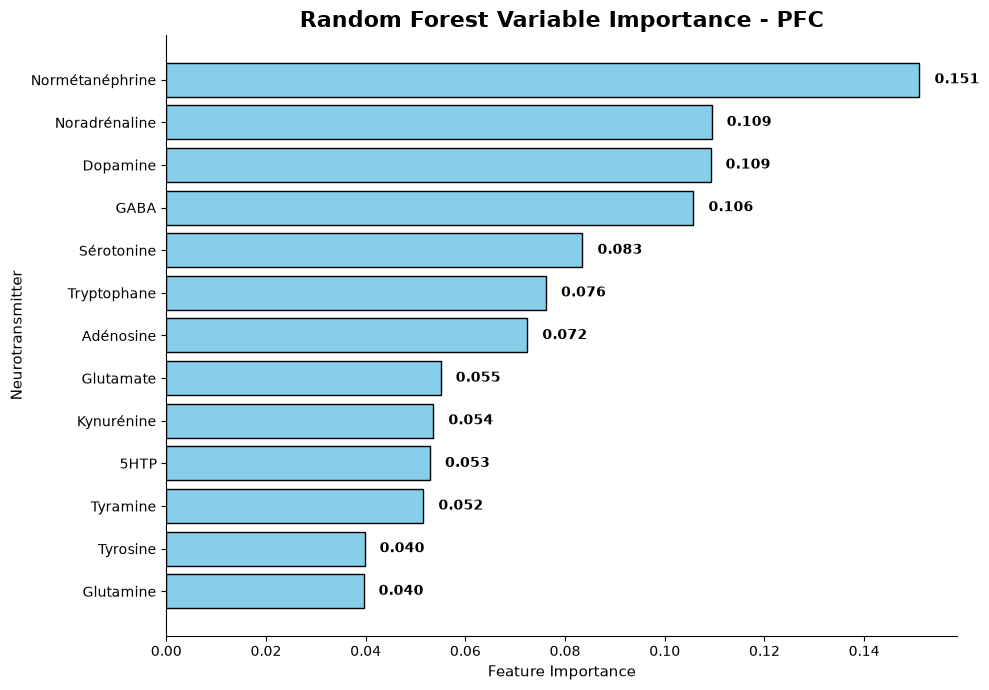

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort for horizontal bar order
rf_plot = rf_importance.sort_values(
    "Importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    rf_plot["NT"],
    rf_plot["Importance"],
    color="skyblue",
    edgecolor="black"
)

# Title and labels
ax.set_title(
    "Random Forest Variable Importance - PFC",
    fontsize=16,
    fontweight="semibold"
)

ax.set_xlabel(
    "Feature Importance",
    fontsize=11
)

ax.set_ylabel(
    "Neurotransmitter",
    fontsize=11
)


# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add importance values
offset = rf_plot["Importance"].max() * 0.02

for bar, value in zip(bars, rf_plot["Importance"]):
    ax.text(
        value + offset,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

<span style="font-weight: bold;"> Random Forest SHAP Analysis
SHAP (SHapley Additive exPlanations) was used to investigate how individual neurotransmitters contributed to the Random Forest predictions.
SHAP values quantify the contribution of each feature to the model output.   
Positive SHAP values indicate that a neurotransmitter pushes the prediction towards the LBN class, while negative values indicate a contribution towards the CONT class. 
The SHAP summary plot provides both the overall importance of each neurotransmitter and the direction of its effect

c:\Users\lydia\Downloads\RE_  Multivariate analyses for the NTS\.NTS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


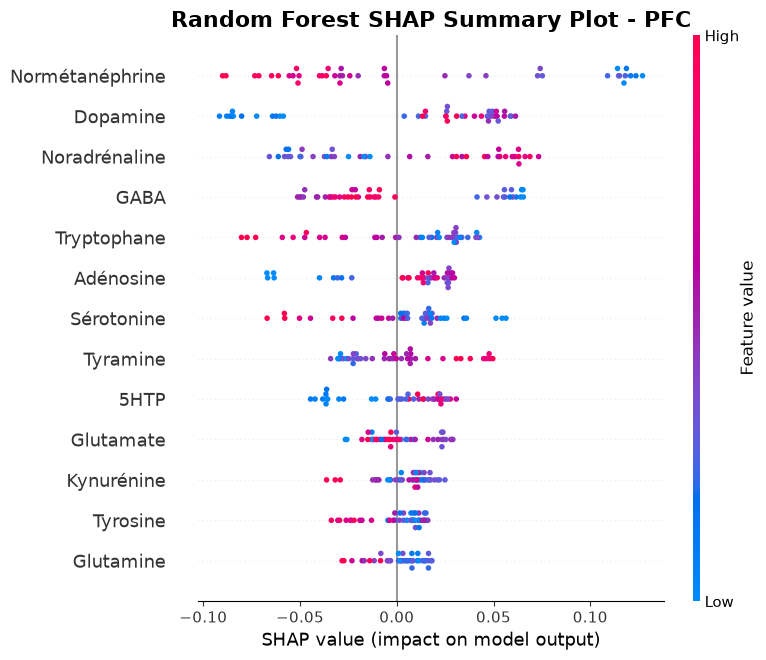

In [73]:
import pandas as pd
import shap
import matplotlib.pyplot as plt



X_imp = pd.DataFrame(
    X_adu_pfc_log,
    columns=X_adu_pfc_log.columns
)

# Extract tuned RF
rf = rf_pipe.named_steps["rf"]

# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_imp)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Plot
shap.summary_plot(
    shap_class1,
    X_imp,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - PFC", fontsize=16, fontweight="semibold")
plt.tight_layout()
plt.show()


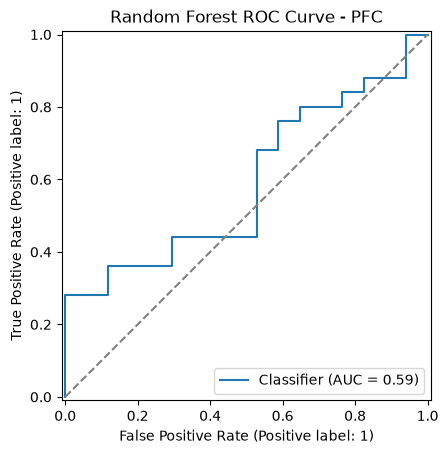

In [74]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_adu_pfc_log,
    Y_adu_pfc,
    cv=cv,
    method="predict_proba"
)[:, 1]

RocCurveDisplay.from_predictions(
    Y_adu_pfc,
    y_prob
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)
plt.title("Random Forest ROC Curve - PFC")
plt.show()

In [75]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

rf_boot = pd.DataFrame(
    columns=X_adu_pfc_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_adu_pfc_log,
        Y_adu_pfc,
        replace=True,
        random_state=i
    )

    # Fit Random Forest
    rf_pipe.fit(
        X_boot,
        Y_boot
    )

    # Save feature importances
    rf_boot.loc[i] = rf_pipe.named_steps["rf"].feature_importances_

In [76]:
rf_summary = pd.DataFrame({
    "Mean": rf_boot.mean(),
    "Lower95": rf_boot.quantile(0.025),
    "Upper95": rf_boot.quantile(0.975)
})

rf_summary = rf_summary.sort_values(
    "Mean",
    ascending=False
)

print(rf_summary)

                     Mean   Lower95   Upper95
Normétanéphrine  0.130574  0.055664  0.223157
Noradrénaline    0.103069  0.038308  0.213026
Dopamine         0.099566  0.037870  0.198975
GABA             0.084247  0.030403  0.165889
Tryptophane      0.079263  0.027073  0.171379
Sérotonine       0.071984  0.028588  0.136144
Adénosine        0.071766  0.026927  0.153367
5HTP             0.070673  0.023097  0.172060
Tyramine         0.065955  0.023423  0.144730
Glutamine        0.060126  0.022607  0.130857
Tyrosine         0.058409  0.024680  0.130986
Kynurénine       0.055727  0.022890  0.123193
Glutamate        0.048642  0.020672  0.097566


---

#### For the HIP

In [77]:
rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(
        n_estimators=200, #Number of trees.
        max_depth=2, #Each tree can only make 2 splits.
        min_samples_leaf=2, #Minimum animals at the end of a branch.
        min_samples_split=4, #Minimum animals to consider a split.
        max_features="sqrt", #Number of features to consider at each split. Random Forest does NOT examine all variables.
        #If every tree always sees all NTs:become very similar. The forest loses diversity. Random feature selection creates more independent trees.
        class_weight="balanced", #Balance the classes.
        random_state=42 #Fixes randomness.
        ))
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

rf_scores = cross_val_score(
    rf_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("===== Random Forest =====")
print("Fold AUCs:", np.round(rf_scores, 3))
print(f"Mean AUC = {rf_scores.mean():.3f}")
print(f"SD = {rf_scores.std():.3f}")

===== Random Forest =====
Fold AUCs: [0.7   0.733 0.8   0.733 0.688 0.65  0.8   0.867 0.867 0.688 0.8   1.
 0.4   0.8   0.75  0.7   0.867 0.8   0.8   1.    0.75  0.4   1.    0.733
 0.875 0.6   0.867 0.467 0.667 0.812 0.75  1.    0.667 0.933 0.75  0.95
 0.933 0.867 0.667 0.625 0.55  0.733 1.    0.8   0.562 0.7   0.733 0.867
 1.    0.625 0.9   0.2   1.    1.    0.688 0.6   0.733 0.867 0.933 0.688
 0.6   0.933 0.667 0.8   0.688 0.8   0.867 0.733 1.    0.688 0.75  0.867
 1.    0.733 0.125 0.55  0.667 0.667 0.8   1.    0.95  0.733 0.867 0.733
 0.75  0.75  0.333 0.933 0.8   0.75  0.8   0.667 0.133 1.    1.    0.5
 1.    0.667 0.8   0.688]
Mean AUC = 0.757
SD = 0.181


<span style="font-weight: bold;"> The Random Forest model achieved a mean ROC-AUC of **0.757 ± 0.181** across 100 repeated stratified cross-validation folds. This indicates that the model has a strong ability to distinguish between the two classes, performing substantially better than random guessing (AUC = 0.5).

<span style="font-weight: bold;">Most folds showed good discrimination (AUC above 0.5), with several folds reaching very high performance (AUC close to 1.0). These results suggest that the Random Forest model provides a relatively stable and effective classification of the two groups, although performance should still be interpreted considering the dataset size.

In [78]:
rf_pipe.fit(X_adu_hip_log, Y_adu_hip)

rf = rf_pipe.named_steps["rf"]

rf_importance = pd.DataFrame({
    "NT": X_adu_hip_log.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

print(rf_importance)

                 NT  Importance
0         Glutamate    0.174414
1     Noradrénaline    0.150085
2       Tryptophane    0.137376
3          Tyrosine    0.104283
4        Kynurénine    0.074591
5              5HTP    0.074335
6         Glutamine    0.061827
7          Dopamine    0.054321
8              GABA    0.046055
9          Tyramine    0.043022
10       Sérotonine    0.031764
11  Normétanéphrine    0.024154
12        Adénosine    0.023773


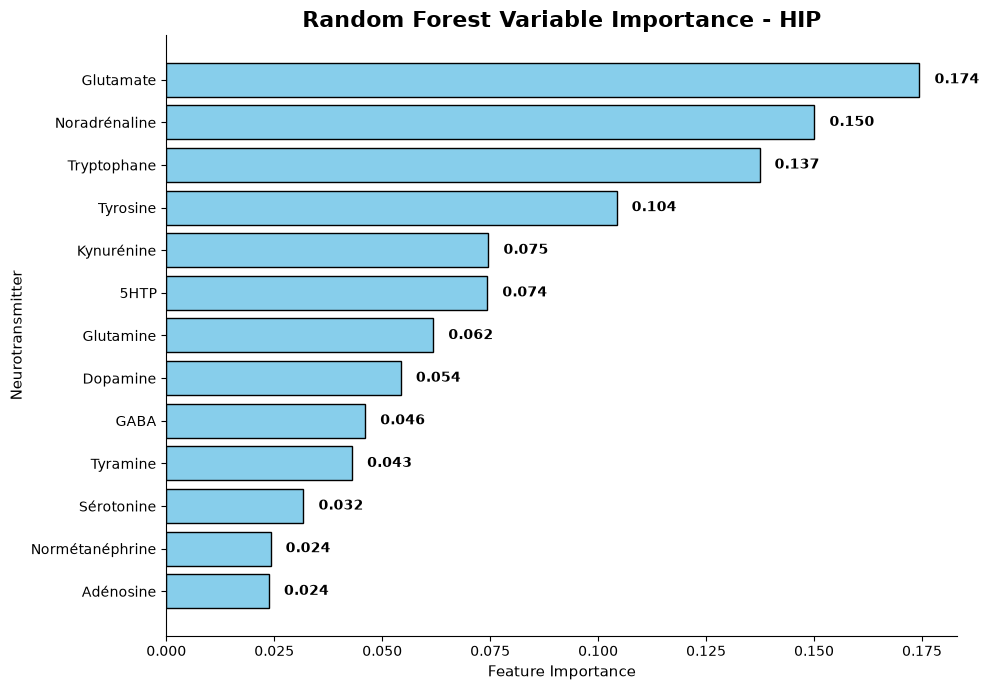

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort for horizontal bar order
rf_plot = rf_importance.sort_values(
    "Importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    rf_plot["NT"],
    rf_plot["Importance"],
    color="skyblue",
    edgecolor="black"
)

# Title and labels
ax.set_title(
    "Random Forest Variable Importance - HIP",
    fontsize=16,
    fontweight="semibold"
)

ax.set_xlabel(
    "Feature Importance",
    fontsize=11
)

ax.set_ylabel(
    "Neurotransmitter",
    fontsize=11
)


# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add importance values
offset = rf_plot["Importance"].max() * 0.02

for bar, value in zip(bars, rf_plot["Importance"]):
    ax.text(
        value + offset,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

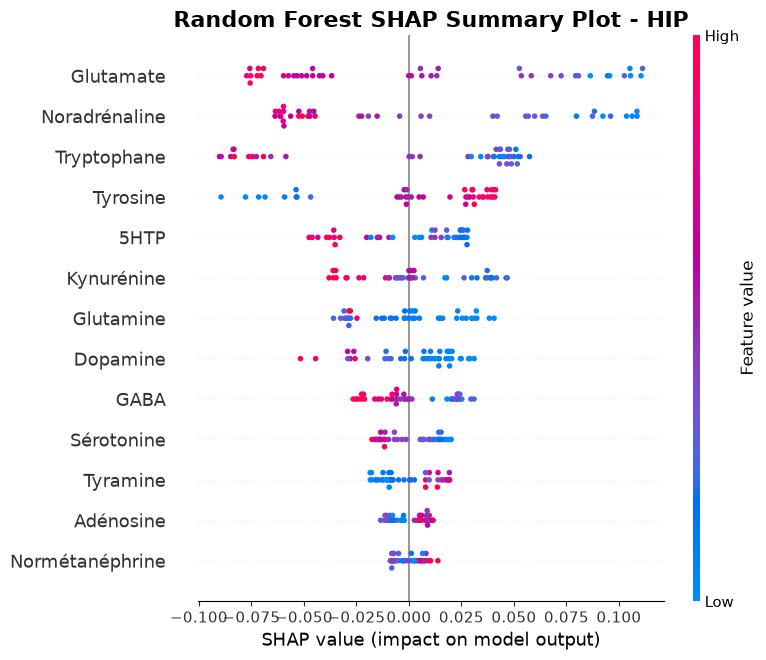

In [80]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

X_imp = pd.DataFrame(
    X_adu_hip_log,
    columns=X_adu_hip_log.columns
)

# Extract tuned RF
rf = rf_pipe.named_steps["rf"]

# SHAP
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_imp)

# Binary classification
shap_class1 = shap_values[:, :, 1]

# Plot
shap.summary_plot(
    shap_class1,
    X_imp,
    show=False
)

plt.title("Random Forest SHAP Summary Plot - HIP", fontsize=16, fontweight="semibold")
plt.tight_layout()
plt.show()


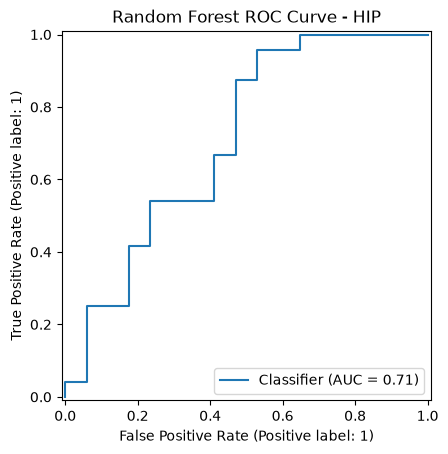

In [81]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

cv_roc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_prob = cross_val_predict(
    rf_pipe,
    X_adu_hip_log,
    Y_adu_hip,
    cv=cv_roc,
    method="predict_proba"
)[:,1]

RocCurveDisplay.from_predictions(
    Y_adu_hip,
    y_prob
)

plt.title("Random Forest ROC Curve - HIP")
plt.show()

In [82]:
import numpy as np
import pandas as pd

from sklearn.utils import resample

n_boot = 1000

rf_boot = pd.DataFrame(
    columns=X_adu_pfc_log.columns
)

for i in range(n_boot):

    # Bootstrap sample
    X_boot, Y_boot = resample(
        X_adu_pfc_log,
        Y_adu_pfc,
        replace=True,
        random_state=i
    )

    # Fit Random Forest
    rf_pipe.fit(
        X_boot,
        Y_boot
    )

    # Save feature importances
    rf_boot.loc[i] = rf_pipe.named_steps["rf"].feature_importances_

In [83]:
rf_summary = pd.DataFrame({
    "Mean": rf_boot.mean(),
    "Lower95": rf_boot.quantile(0.025),
    "Upper95": rf_boot.quantile(0.975)
})

rf_summary = rf_summary.sort_values(
    "Mean",
    ascending=False
)

print(rf_summary)

                     Mean   Lower95   Upper95
Normétanéphrine  0.141462  0.052907  0.240182
Noradrénaline    0.109471  0.032258  0.233242
Dopamine         0.099043  0.032160  0.207415
GABA             0.087436  0.026993  0.174971
Tryptophane      0.077065  0.020093  0.177706
Adénosine        0.071317  0.022345  0.162594
5HTP             0.069722  0.016080  0.183432
Sérotonine       0.064893  0.021501  0.134743
Glutamine        0.060709  0.017801  0.142642
Tyramine         0.059174  0.016494  0.140677
Tyrosine         0.057202  0.018898  0.137919
Kynurénine       0.055813  0.018474  0.137753
Glutamate        0.046692  0.014964  0.103039
